# 🛒 Bangladesh E-Commerce Customer & Sales Analytics
## Introduction to Programming — Final Project
**National University, Bangladesh**

---

| Field | Details |
|---|---|
| **Dataset** | Bangladesh E-Commerce Customer & Sales (2023–2024) |
| **Rows** | ~11,090 |
| **Columns** | 23 |
| **Tools** | Python, Pandas, NumPy, Matplotlib, Seaborn, Scikit-learn |
| **Models** | Linear Regression · Random Forest Classifier · K-Means Clustering |

---


## 1. 📌 Problem Definition

### Background
The e-commerce sector in Bangladesh has grown rapidly over the past decade, powered by mobile financial services like bKash and Nagad, along with increased smartphone penetration.  
Despite this growth, many businesses struggle with **high churn rates**, **product returns**, and **inefficient marketing spend**.

### Problem Statement
> *Can we use historical customer transaction data to understand purchasing behaviour, predict customer churn, and segment customers into meaningful groups — enabling data-driven business decisions?*

### Objectives
1. **Clean & prepare** real-world messy sales data for analysis.
2. **Explore** patterns in customer spending, product preferences, delivery performance, and seasonal trends.
3. **Predict customer churn** using a classification model.
4. **Predict order value** using a regression model.
5. **Segment customers** using clustering to enable targeted marketing.

### Why is this important?
- Reducing churn by even 5% can increase profits by 25–95% (Harvard Business Review).
- Understanding seasonal demand (e.g., Eid peaks) helps with inventory and logistics.
- Customer segmentation enables personalised promotions, lowering acquisition costs.


## 2. 📦 Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.cluster import KMeans
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score,
    accuracy_score, classification_report, confusion_matrix,
    silhouette_score
)
from sklearn.decomposition import PCA
from scipy import stats

# ── Plotting style ──────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi': 130,
    'figure.facecolor': 'white',
    'axes.facecolor': '#f9f9f9',
    'axes.grid': True,
    'grid.alpha': 0.4,
    'font.family': 'DejaVu Sans',
    'axes.spines.top': False,
    'axes.spines.right': False,
})
PALETTE = ['#2563eb','#f59e0b','#10b981','#ef4444','#8b5cf6','#06b6d4','#f97316','#84cc16']
sns.set_palette(PALETTE)

print("✅ All libraries imported successfully.")


✅ All libraries imported successfully.


## 3. 📂 Data Collection

### Source
The dataset was compiled to represent the Bangladesh e-commerce market (2023–2024).  
It covers 8 product categories, 10 major cities, and records such as payment methods, delivery times, ratings, and customer demographics.

| Attribute | Details |
|---|---|
| Format | CSV (`.csv`) |
| Rows | ~11,090 |
| Columns | 23 |
| Time Range | Jan 2023 – Dec 2024 |
| Data Types | Numerical, Categorical, Date, Binary |


In [2]:
# Load the dataset
df_raw = pd.read_csv('TanvirAhmed_Reg_00022_ecommerce_dataset.csv')

print(f"Dataset shape: {df_raw.shape}")
print(f"\nColumn names:\n{list(df_raw.columns)}")
df_raw.head()


Dataset shape: (11090, 23)

Column names:
['Order_ID', 'Customer_ID', 'Age', 'Gender', 'City', 'Income_Level', 'Education', 'Occupation', 'Product_Category', 'Product_Name', 'Unit_Price', 'Quantity', 'Discount_Percent', 'Total_Amount', 'Payment_Method', 'Order_Date', 'Delivery_Days', 'Rating', 'Is_Returned', 'Repeat_Purchase', 'Satisfaction_Score', 'Loyalty_Points', 'Is_Churned']


,Order_ID,Customer_ID,Age,Gender,City,Income_Level,Education,Occupation,Product_Category,Product_Name,...,Total_Amount,Payment_Method,Order_Date,Delivery_Days,Rating,Is_Returned,Repeat_Purchase,Satisfaction_Score,Loyalty_Points,Is_Churned
0,ORD001892,CUST03060,36.0,Male,Rangpur,Lower-Middle,HSC,Teacher,Fashion,Sneakers,...,1913.05,Debit Card,21-09-24,3.0,4.0,0,0,6.8,38,0
1,ORD009165,CUST00271,34.0,Male,Chattogram,Upper-Middle,Bachelor,Homemaker,Sports,Badminton Racket,...,885.12,Credit Card,17-10-24,4.0,5.0,0,1,9.4,17,0
2,ORD003903,CUST03079,34.0,Male,Dhaka,Upper-Middle,HSC,Homemaker,Electronics,Power Bank,...,1784.27,Credit Card,30-01-23,2.0,3.0,0,1,4.5,35,0
3,ORD006287,CUST00594,34.0,Female,Chattogram,High,Below SSC,Service Holder,Fashion,Handbag,...,4751.46,Nagad,29-10-23,6.0,5.0,0,1,9.0,95,0
4,ORD000884,CUST01996,34.0,Female,Dhaka,Low,PhD,Freelancer,Beauty,Sunscreen,...,378.81,Rocket,21-05-24,2.0,4.0,0,1,6.6,7,0


In [8]:
# Quick info
df_raw.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11090 entries, 0 to 11089
Data columns (total 23 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Order_ID            11090 non-null  object 
 1   Customer_ID         11090 non-null  object 
 2   Age                 10476 non-null  float64
 3   Gender              11090 non-null  object 
 4   City                11090 non-null  object 
 5   Income_Level        10478 non-null  object 
 6   Education           10483 non-null  object 
 7   Occupation          10479 non-null  object 
 8   Product_Category    11090 non-null  object 
 9   Product_Name        11090 non-null  object 
 10  Unit_Price          11090 non-null  int64  
 11  Quantity            11090 non-null  int64  
 12  Discount_Percent    10484 non-null  float64
 13  Total_Amount        11090 non-null  float64
 14  Payment_Method      11090 non-null  object 
 15  Order_Date          11090 non-null  object 
 16  Deli

In [9]:
# Basic statistics
df_raw.describe(include='all').T.style.background_gradient(cmap='Blues', subset=['mean','std'])


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Order_ID,11090,11000,ORD001769,2,nan,nan,nan,nan,nan,nan,nan
Customer_ID,11090,3727,CUST00637,9,nan,nan,nan,nan,nan,nan,nan
Age,10476.000000,nan,nan,nan,29.921344,8.126466,18.000000,23.000000,30.000000,36.000000,63.000000
Gender,11090,3,Male,5708,nan,nan,nan,nan,nan,nan,nan
City,11090,10,Dhaka,3890,nan,nan,nan,nan,nan,nan,nan
Income_Level,10478,5,Middle,3139,nan,nan,nan,nan,nan,nan,nan
Education,10483,6,Bachelor,3620,nan,nan,nan,nan,nan,nan,nan
Occupation,10479,8,Service Holder,2640,nan,nan,nan,nan,nan,nan,nan
Product_Category,11090,8,Electronics,2242,nan,nan,nan,nan,nan,nan,nan
Product_Name,11090,45,Smartphone,412,nan,nan,nan,nan,nan,nan,nan


## 4. 🧹 Data Preprocessing & Cleaning

The raw dataset intentionally contains:
- **Missing values** in demographic & transactional columns
- **Duplicate rows** from data entry errors
- **Outliers** in `Total_Amount` and negative `Discount_Percent`

We will handle each systematically.


### 4.1 Handling Missing Values

                    Missing Count  Missing %
Satisfaction_Score            615       5.55
Age                           614       5.54
Delivery_Days                 612       5.52
Income_Level                  612       5.52
Occupation                    611       5.51
Rating                        609       5.49
Education                     607       5.47
Discount_Percent              606       5.46


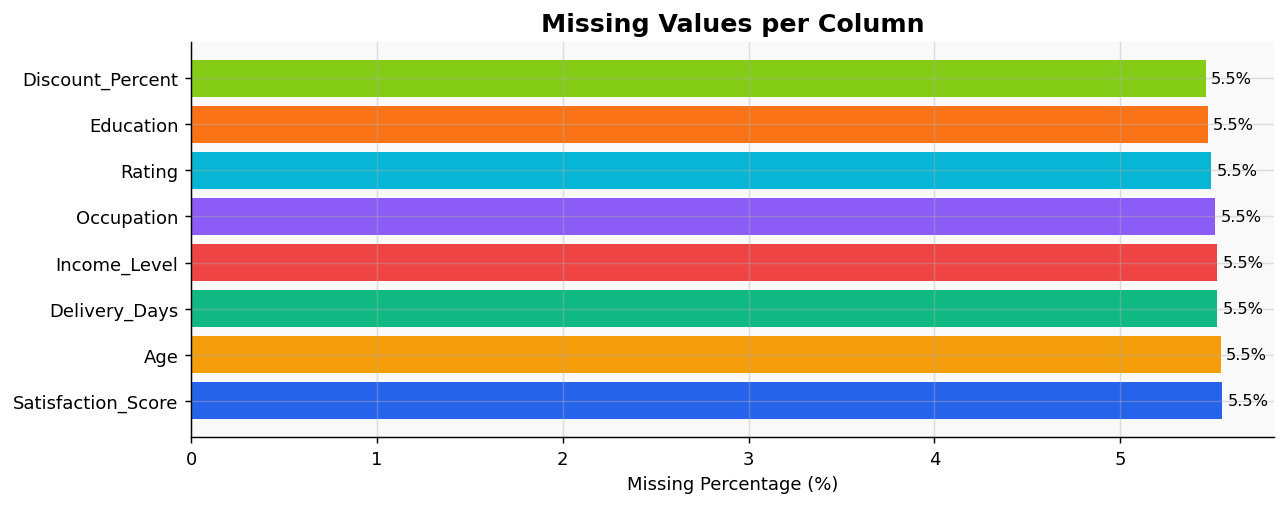

In [10]:
# Visualise missing values
missing = df_raw.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
missing_pct = (missing / len(df_raw) * 100).round(2)

missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
print(missing_df)

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.barh(missing_df.index, missing_df['Missing %'], color=PALETTE[:len(missing_df)])
ax.bar_label(bars, fmt='%.1f%%', padding=3, fontsize=9)
ax.set_xlabel('Missing Percentage (%)')
ax.set_title('Missing Values per Column', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


In [11]:
# Work on a copy
df = df_raw.copy()

# ── Numerical columns: fill with median (robust to outliers) ─
num_fill = ['Age', 'Discount_Percent', 'Delivery_Days', 'Rating', 'Satisfaction_Score']
for col in num_fill:
    median_val = df[col].median()
    df[col] = df[col].fillna(median_val)
    print(f"  {col}: filled {df_raw[col].isnull().sum()} NaNs with median = {median_val:.2f}")

# ── Categorical columns: fill with mode ─────────────────────
cat_fill = ['Income_Level', 'Education', 'Occupation']
for col in cat_fill:
    mode_val = df[col].mode()[0]
    df[col] = df[col].fillna(mode_val)
    print(f"  {col}: filled {df_raw[col].isnull().sum()} NaNs with mode = '{mode_val}'")

print(f"\nRemaining missing values: {df.isnull().sum().sum()}")


  Age: filled 614 NaNs with median = 30.00
  Discount_Percent: filled 606 NaNs with median = 4.90
  Delivery_Days: filled 612 NaNs with median = 3.00
  Rating: filled 609 NaNs with median = 4.00
  Satisfaction_Score: filled 615 NaNs with median = 7.20
  Income_Level: filled 612 NaNs with mode = 'Middle'
  Education: filled 607 NaNs with mode = 'Bachelor'
  Occupation: filled 611 NaNs with mode = 'Service Holder'

Remaining missing values: 0


### 4.2 Handling Duplicates

In [12]:
print(f"Duplicate rows before cleaning: {df.duplicated().sum()}")

df = df.drop_duplicates()
df = df.reset_index(drop=True)

print(f"Duplicate rows after cleaning : {df.duplicated().sum()}")
print(f"Dataset shape after removing duplicates: {df.shape}")


Duplicate rows before cleaning: 89
Duplicate rows after cleaning : 0
Dataset shape after removing duplicates: (11001, 23)


### 4.3 Detecting & Handling Outliers

Total_Amount outliers detected (IQR): 1661
  Lower bound: -3831.97 BDT
  Upper bound: 7722.55 BDT


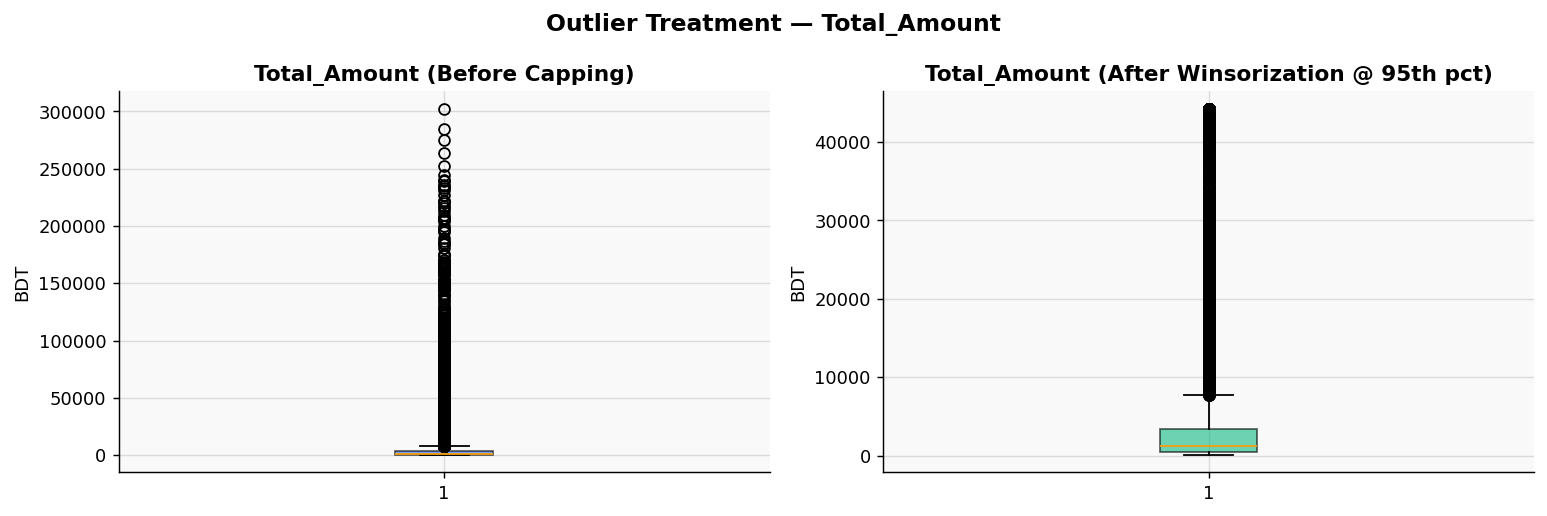

In [13]:
# ── IQR method on Total_Amount ──────────────────────────────
Q1 = df['Total_Amount'].quantile(0.25)
Q3 = df['Total_Amount'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df['Total_Amount'] < lower_bound) | (df['Total_Amount'] > upper_bound)]
print(f"Total_Amount outliers detected (IQR): {len(outliers)}")
print(f"  Lower bound: {lower_bound:.2f} BDT")
print(f"  Upper bound: {upper_bound:.2f} BDT")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].boxplot(df['Total_Amount'], patch_artist=True,
                boxprops=dict(facecolor='#2563eb', alpha=0.6))
axes[0].set_title('Total_Amount (Before Capping)', fontweight='bold')
axes[0].set_ylabel('BDT')

# Cap outliers using Winsorization (95th percentile cap)
cap_upper = df['Total_Amount'].quantile(0.95)
df['Total_Amount'] = df['Total_Amount'].clip(upper=cap_upper)

axes[1].boxplot(df['Total_Amount'], patch_artist=True,
                boxprops=dict(facecolor='#10b981', alpha=0.6))
axes[1].set_title('Total_Amount (After Winsorization @ 95th pct)', fontweight='bold')
axes[1].set_ylabel('BDT')
plt.suptitle('Outlier Treatment — Total_Amount', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


In [14]:
# ── Fix negative Discount_Percent ───────────────────────────
neg_disc = (df['Discount_Percent'] < 0).sum()
print(f"Negative Discount_Percent entries: {neg_disc}")
df['Discount_Percent'] = df['Discount_Percent'].abs()
print(f"Fixed. All discounts now >= 0.")

# ── Z-score check on Unit_Price ─────────────────────────────
z_scores = np.abs(stats.zscore(df['Unit_Price']))
extreme = (z_scores > 3).sum()
print(f"\nUnit_Price entries with |Z| > 3: {extreme} (kept — valid high-value electronics)")


Negative Discount_Percent entries: 14
Fixed. All discounts now >= 0.

Unit_Price entries with |Z| > 3: 365 (kept — valid high-value electronics)


### 4.4 Data Type Conversion & Transformation

In [15]:
# Convert Order_Date to datetime
df['Order_Date'] = pd.to_datetime(df['Order_Date'])

# Extract time features
df['Order_Month']     = df['Order_Date'].dt.month
df['Order_Quarter']   = df['Order_Date'].dt.quarter
df['Order_Year']      = df['Order_Date'].dt.year
df['Order_DayOfWeek'] = df['Order_Date'].dt.dayofweek   # 0=Mon

# Round floats
df['Age']              = df['Age'].round(0).astype(int)
df['Delivery_Days']    = df['Delivery_Days'].round(0).astype(int)
df['Rating']           = df['Rating'].round(0).astype(int)

print("✅ Date features extracted. Data types corrected.")
print(df[['Order_Date','Order_Month','Order_Quarter','Order_Year','Order_DayOfWeek']].head())


✅ Date features extracted. Data types corrected.
  Order_Date  Order_Month  Order_Quarter  Order_Year  Order_DayOfWeek
0 2024-09-21            9              3        2024                5
1 2024-10-17           10              4        2024                3
2 2023-01-30            1              1        2023                0
3 2023-10-29           10              4        2023                6
4 2024-05-21            5              2        2024                1


### 4.5 Feature Engineering

In [16]:
# 1. Revenue per unit (price efficiency)
df['Revenue_Per_Unit'] = df['Total_Amount'] / df['Quantity']

# 2. Discount amount in BDT
df['Discount_Amount_BDT'] = (df['Unit_Price'] * df['Quantity'] * df['Discount_Percent'] / 100).round(2)

# 3. Is weekend order?
df['Is_Weekend'] = (df['Order_DayOfWeek'] >= 5).astype(int)

# 4. Is Eid season? (April=4, May=5)
df['Is_Eid_Season'] = df['Order_Month'].isin([4, 5]).astype(int)

# 5. Age group
bins = [17, 24, 34, 44, 54, 65]
labels = ['18-24', '25-34', '35-44', '45-54', '55-65']
df['Age_Group'] = pd.cut(df['Age'], bins=bins, labels=labels)

# 6. High value order flag (above 75th percentile)
high_val_threshold = df['Total_Amount'].quantile(0.75)
df['Is_High_Value_Order'] = (df['Total_Amount'] >= high_val_threshold).astype(int)

print("✅ New features created:")
new_features = ['Revenue_Per_Unit','Discount_Amount_BDT','Is_Weekend',
                'Is_Eid_Season','Age_Group','Is_High_Value_Order']
print(df[new_features].head())
print(f"\nDataset shape after feature engineering: {df.shape}")


✅ New features created:
   Revenue_Per_Unit  Discount_Amount_BDT  Is_Weekend  Is_Eid_Season Age_Group  \
0          1913.050               119.95           1              0     35-44   
1           885.120                74.88           0              0     25-34   
2           892.135               297.73           0              0     25-34   
3          1583.820               276.54           1              0     25-34   
4           378.810                35.19           0              1     25-34   

   Is_High_Value_Order  
0                    0  
1                    0  
2                    0  
3                    1  
4                    0  

Dataset shape after feature engineering: (11001, 33)


In [17]:
# Final clean dataset summary
print("=" * 55)
print("     CLEANED DATASET SUMMARY")
print("=" * 55)
print(f"  Total rows             : {len(df):,}")
print(f"  Total columns          : {df.shape[1]}")
print(f"  Missing values         : {df.isnull().sum().sum()}")
print(f"  Duplicates             : {df.duplicated().sum()}")
print(f"  Date range             : {df['Order_Date'].min().date()} → {df['Order_Date'].max().date()}")
print(f"  Unique customers       : {df['Customer_ID'].nunique():,}")
print(f"  Unique products        : {df['Product_Name'].nunique()}")
print(f"  Avg Total Amount (BDT) : {df['Total_Amount'].mean():,.0f}")
print("=" * 55)


     CLEANED DATASET SUMMARY
  Total rows             : 11,001
  Total columns          : 33
  Missing values         : 0
  Duplicates             : 0
  Date range             : 2023-01-01 → 2024-12-31
  Unique customers       : 3,727
  Unique products        : 45
  Avg Total Amount (BDT) : 5,519


## 5. 🔍 Exploratory Data Analysis (EDA)

We explore the data across four lenses:
1. Univariate distributions
2. Categorical breakdowns
3. Bivariate & correlation analysis
4. Time-series trends


### 5.1 Statistical Summary

In [18]:
key_cols = ['Age','Unit_Price','Quantity','Discount_Percent',
            'Total_Amount','Delivery_Days','Rating','Satisfaction_Score','Loyalty_Points']
df[key_cols].describe().T.style.format('{:.2f}').background_gradient(cmap='YlOrRd', subset=['mean','std','max'])


,count,mean,std,min,25%,50%,75%,max
Age,11001.00,29.93,7.90,18.00,24.00,30.00,35.00,63.00
Unit_Price,11001.00,4554.29,11177.73,68.00,395.00,824.00,2139.00,65998.00
Quantity,11001.00,1.78,1.09,1.00,1.00,1.00,2.00,5.00
Discount_Percent,11001.00,5.80,4.12,0.00,2.60,4.90,8.20,18.00
Total_Amount,11001.00,5519.01,11035.74,64.87,500.97,1204.07,3389.60,44267.12
Delivery_Days,11001.00,3.22,1.47,1.00,2.00,3.00,4.00,9.00
Rating,11001.00,3.84,1.03,1.00,3.00,4.00,5.00,5.00
Satisfaction_Score,11001.00,6.91,1.91,1.00,5.80,7.20,8.40,10.00
Loyalty_Points,11001.00,149.91,435.36,1.00,9.00,23.00,66.00,6048.00


### 5.2 Univariate Analysis — Numerical Features

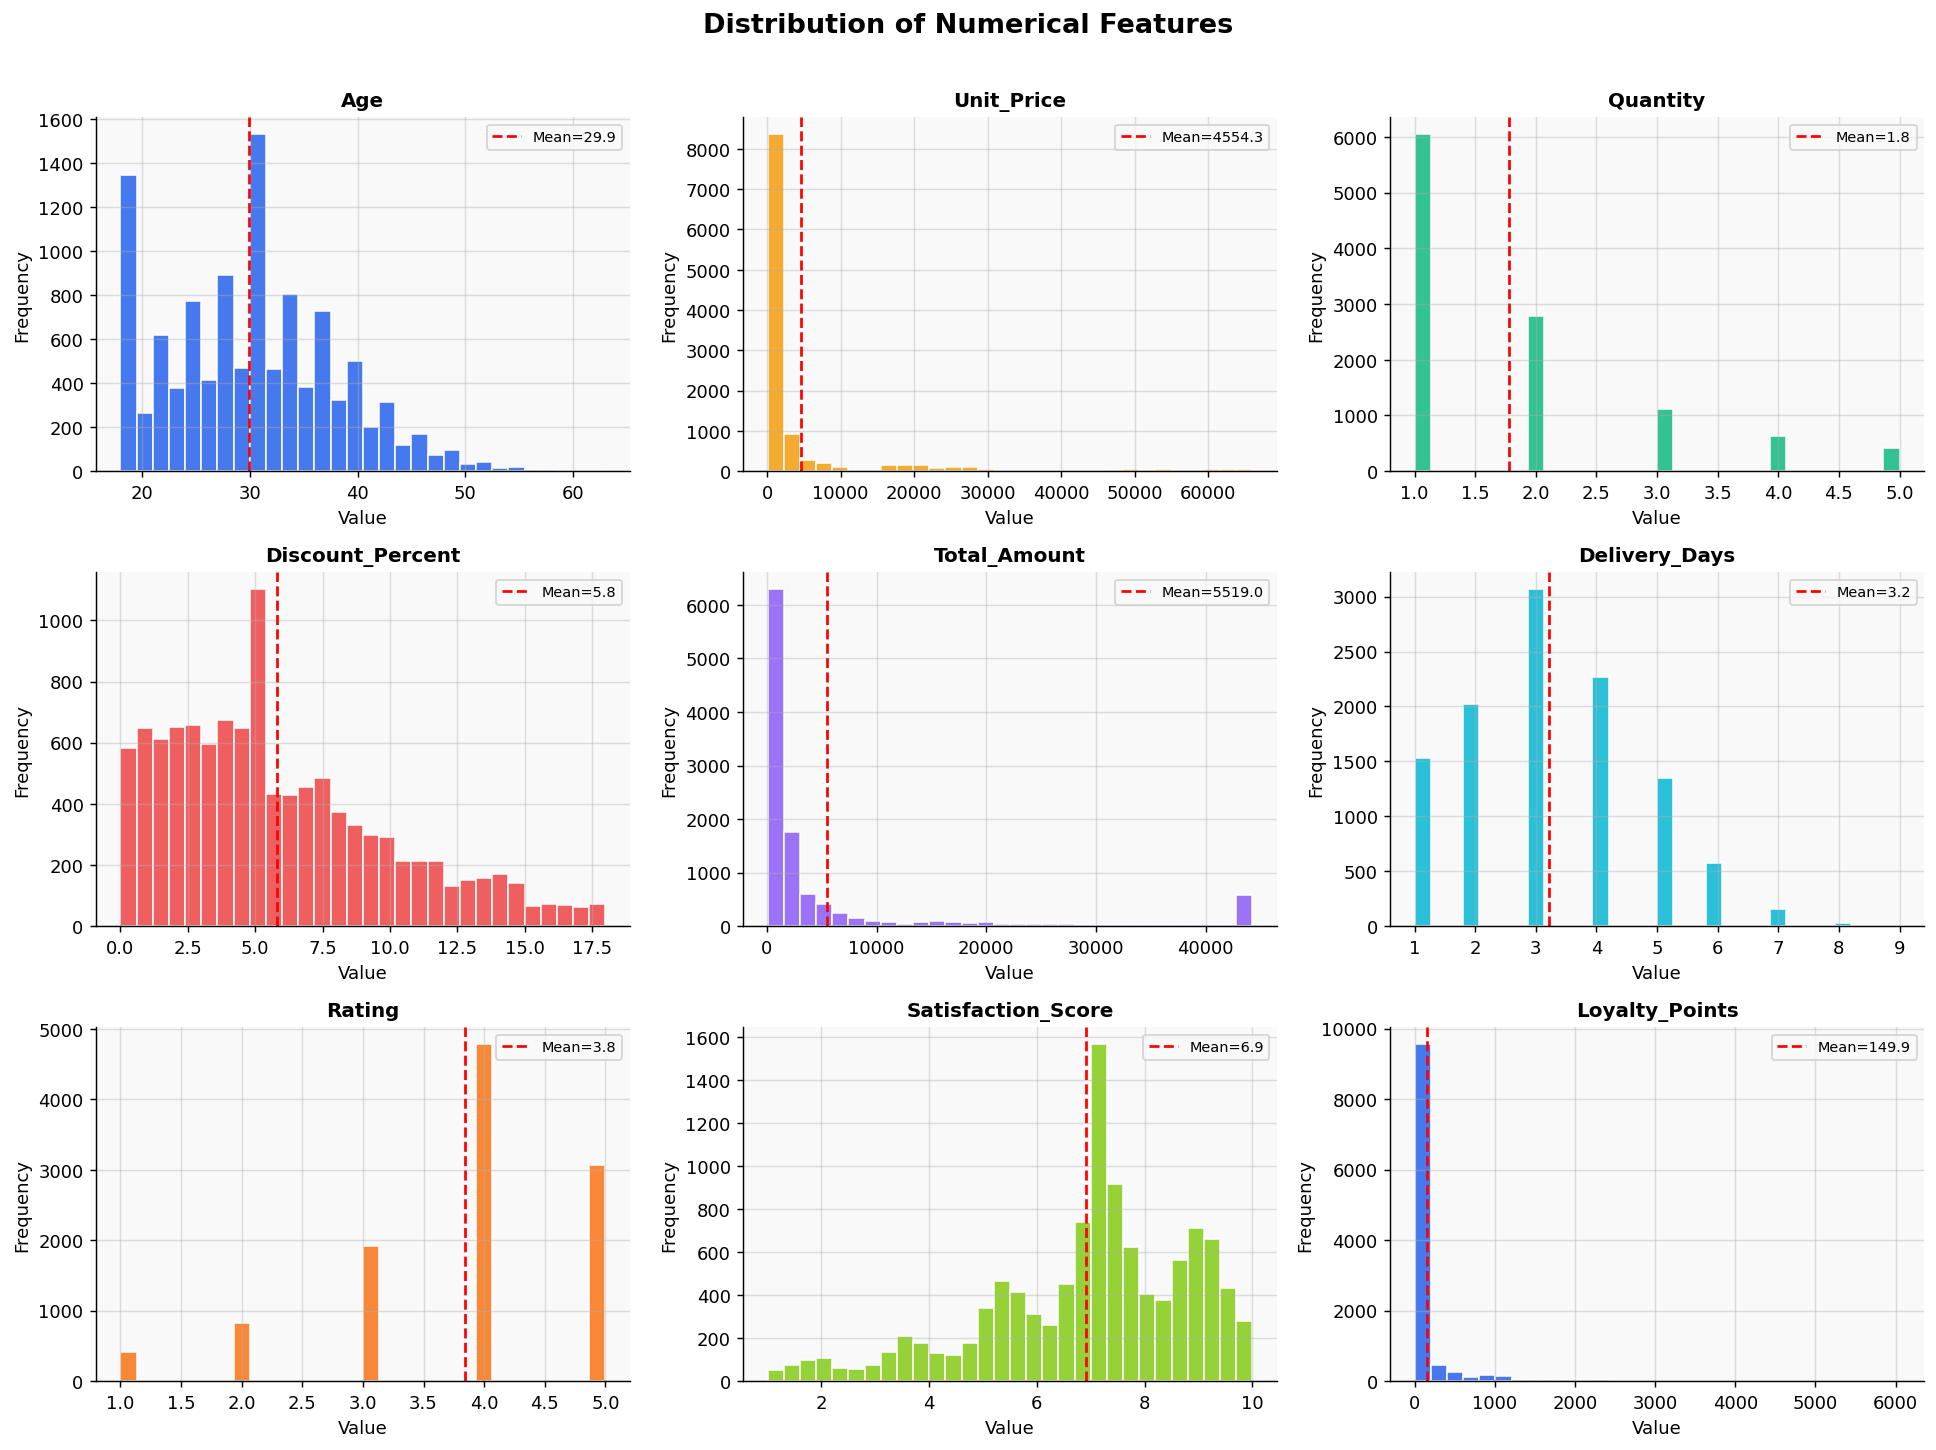

In [19]:
fig, axes = plt.subplots(3, 3, figsize=(15, 11))
axes = axes.flatten()

plot_cols = ['Age', 'Unit_Price', 'Quantity', 'Discount_Percent',
             'Total_Amount', 'Delivery_Days', 'Rating', 'Satisfaction_Score', 'Loyalty_Points']

for i, col in enumerate(plot_cols):
    axes[i].hist(df[col], bins=30, color=PALETTE[i % len(PALETTE)], edgecolor='white', alpha=0.85)
    axes[i].set_title(col, fontweight='bold', fontsize=11)
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Frequency')
    mean_val = df[col].mean()
    axes[i].axvline(mean_val, color='red', linestyle='--', linewidth=1.5, label=f'Mean={mean_val:.1f}')
    axes[i].legend(fontsize=8)

plt.suptitle('Distribution of Numerical Features', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


### 5.3 Categorical Feature Analysis

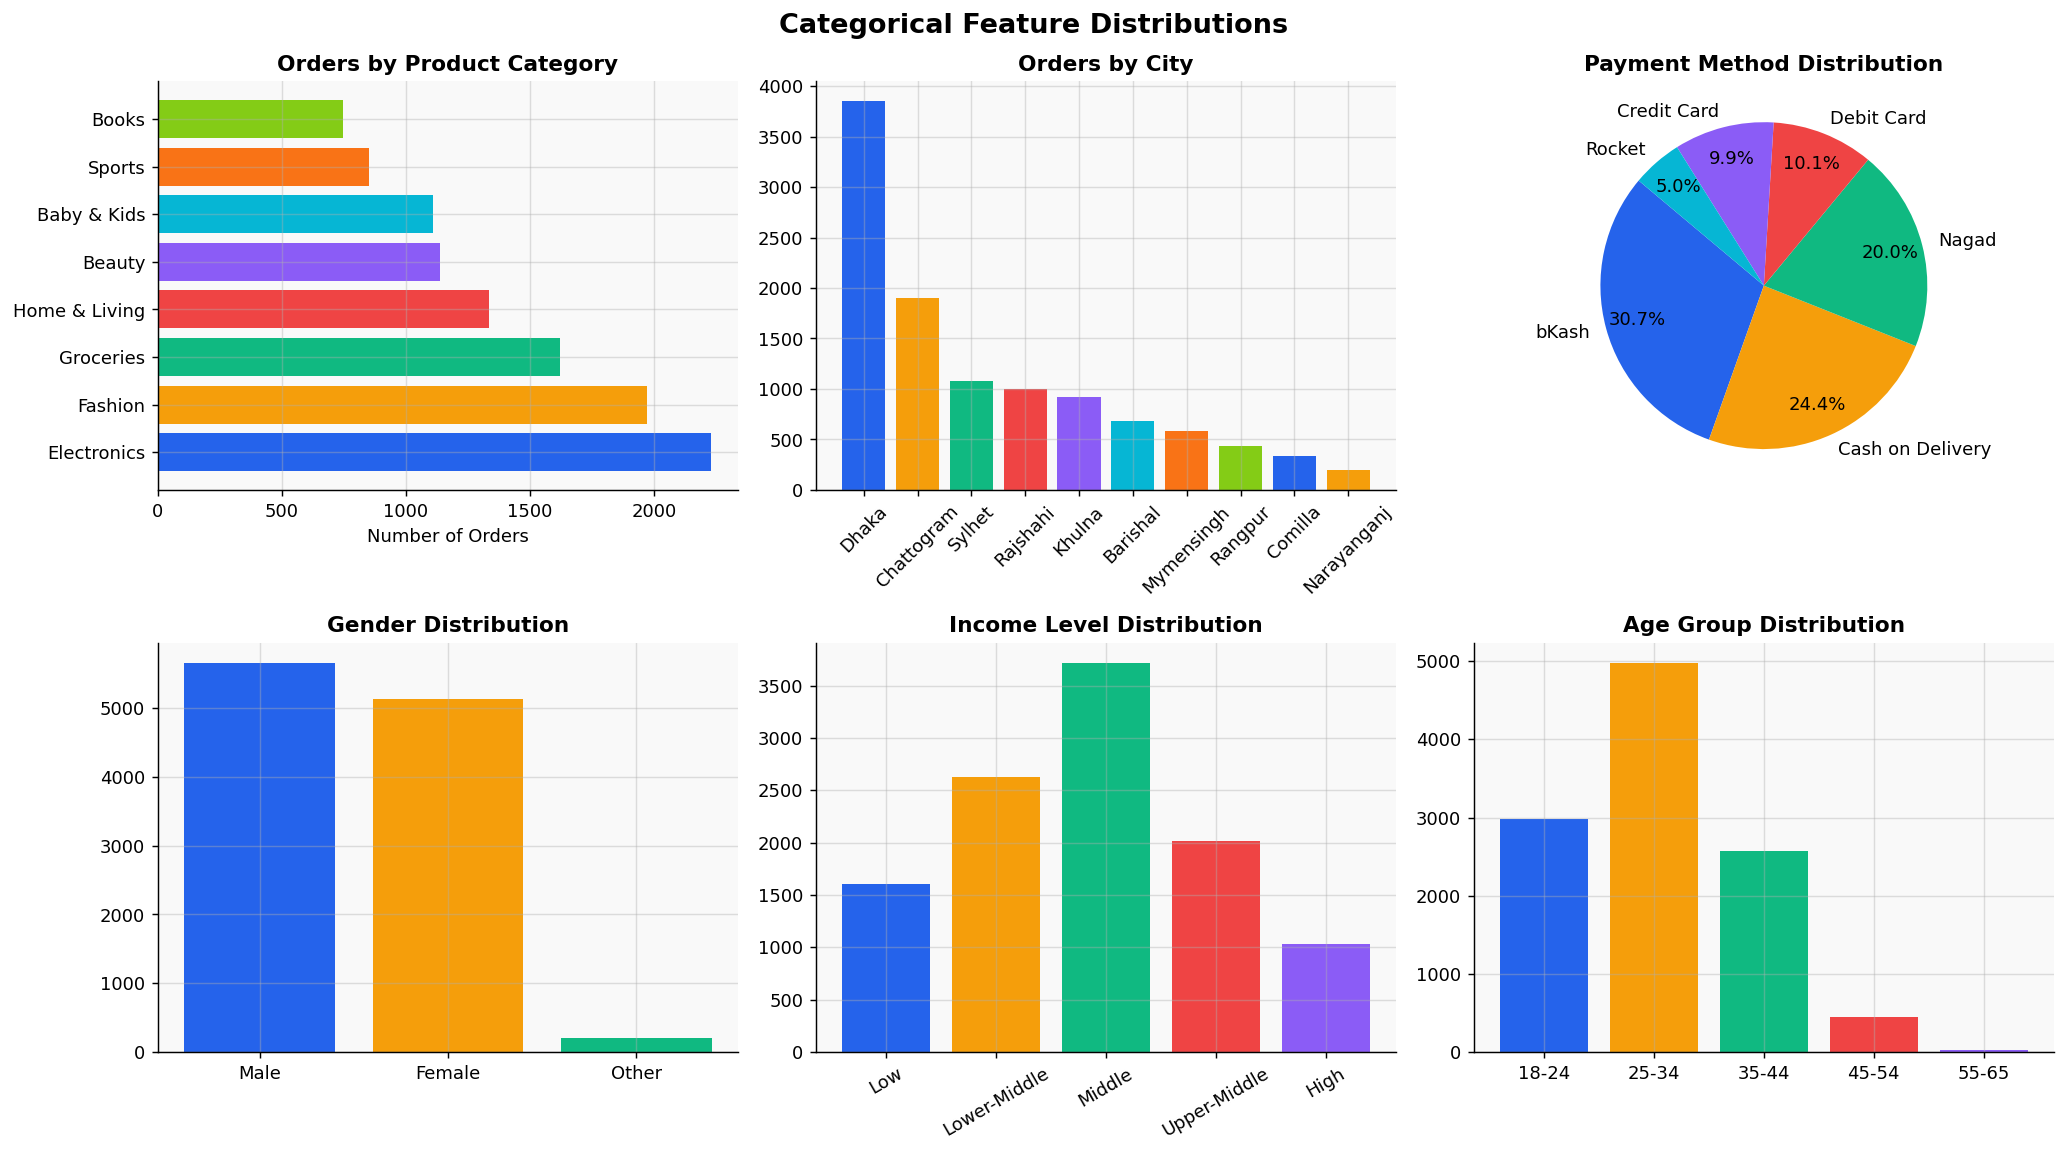

In [20]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

# Product Category
cat_counts = df['Product_Category'].value_counts()
axes[0][0].barh(cat_counts.index, cat_counts.values, color=PALETTE)
axes[0][0].set_title('Orders by Product Category', fontweight='bold')
axes[0][0].set_xlabel('Number of Orders')

# City
city_counts = df['City'].value_counts()
axes[0][1].bar(city_counts.index, city_counts.values, color=PALETTE)
axes[0][1].set_title('Orders by City', fontweight='bold')
axes[0][1].tick_params(axis='x', rotation=45)

# Payment Method
pay_counts = df['Payment_Method'].value_counts()
axes[0][2].pie(pay_counts.values, labels=pay_counts.index, autopct='%1.1f%%',
               colors=PALETTE, startangle=140, pctdistance=0.8)
axes[0][2].set_title('Payment Method Distribution', fontweight='bold')

# Gender
gen_counts = df['Gender'].value_counts()
axes[1][0].bar(gen_counts.index, gen_counts.values, color=PALETTE[:3])
axes[1][0].set_title('Gender Distribution', fontweight='bold')

# Income Level
income_order = ['Low','Lower-Middle','Middle','Upper-Middle','High']
income_counts = df['Income_Level'].value_counts().reindex(income_order)
axes[1][1].bar(income_counts.index, income_counts.values, color=PALETTE)
axes[1][1].set_title('Income Level Distribution', fontweight='bold')
axes[1][1].tick_params(axis='x', rotation=30)

# Age Group
age_counts = df['Age_Group'].value_counts().sort_index()
axes[1][2].bar(age_counts.index.astype(str), age_counts.values, color=PALETTE)
axes[1][2].set_title('Age Group Distribution', fontweight='bold')

plt.suptitle('Categorical Feature Distributions', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()


### 5.4 Bivariate Analysis

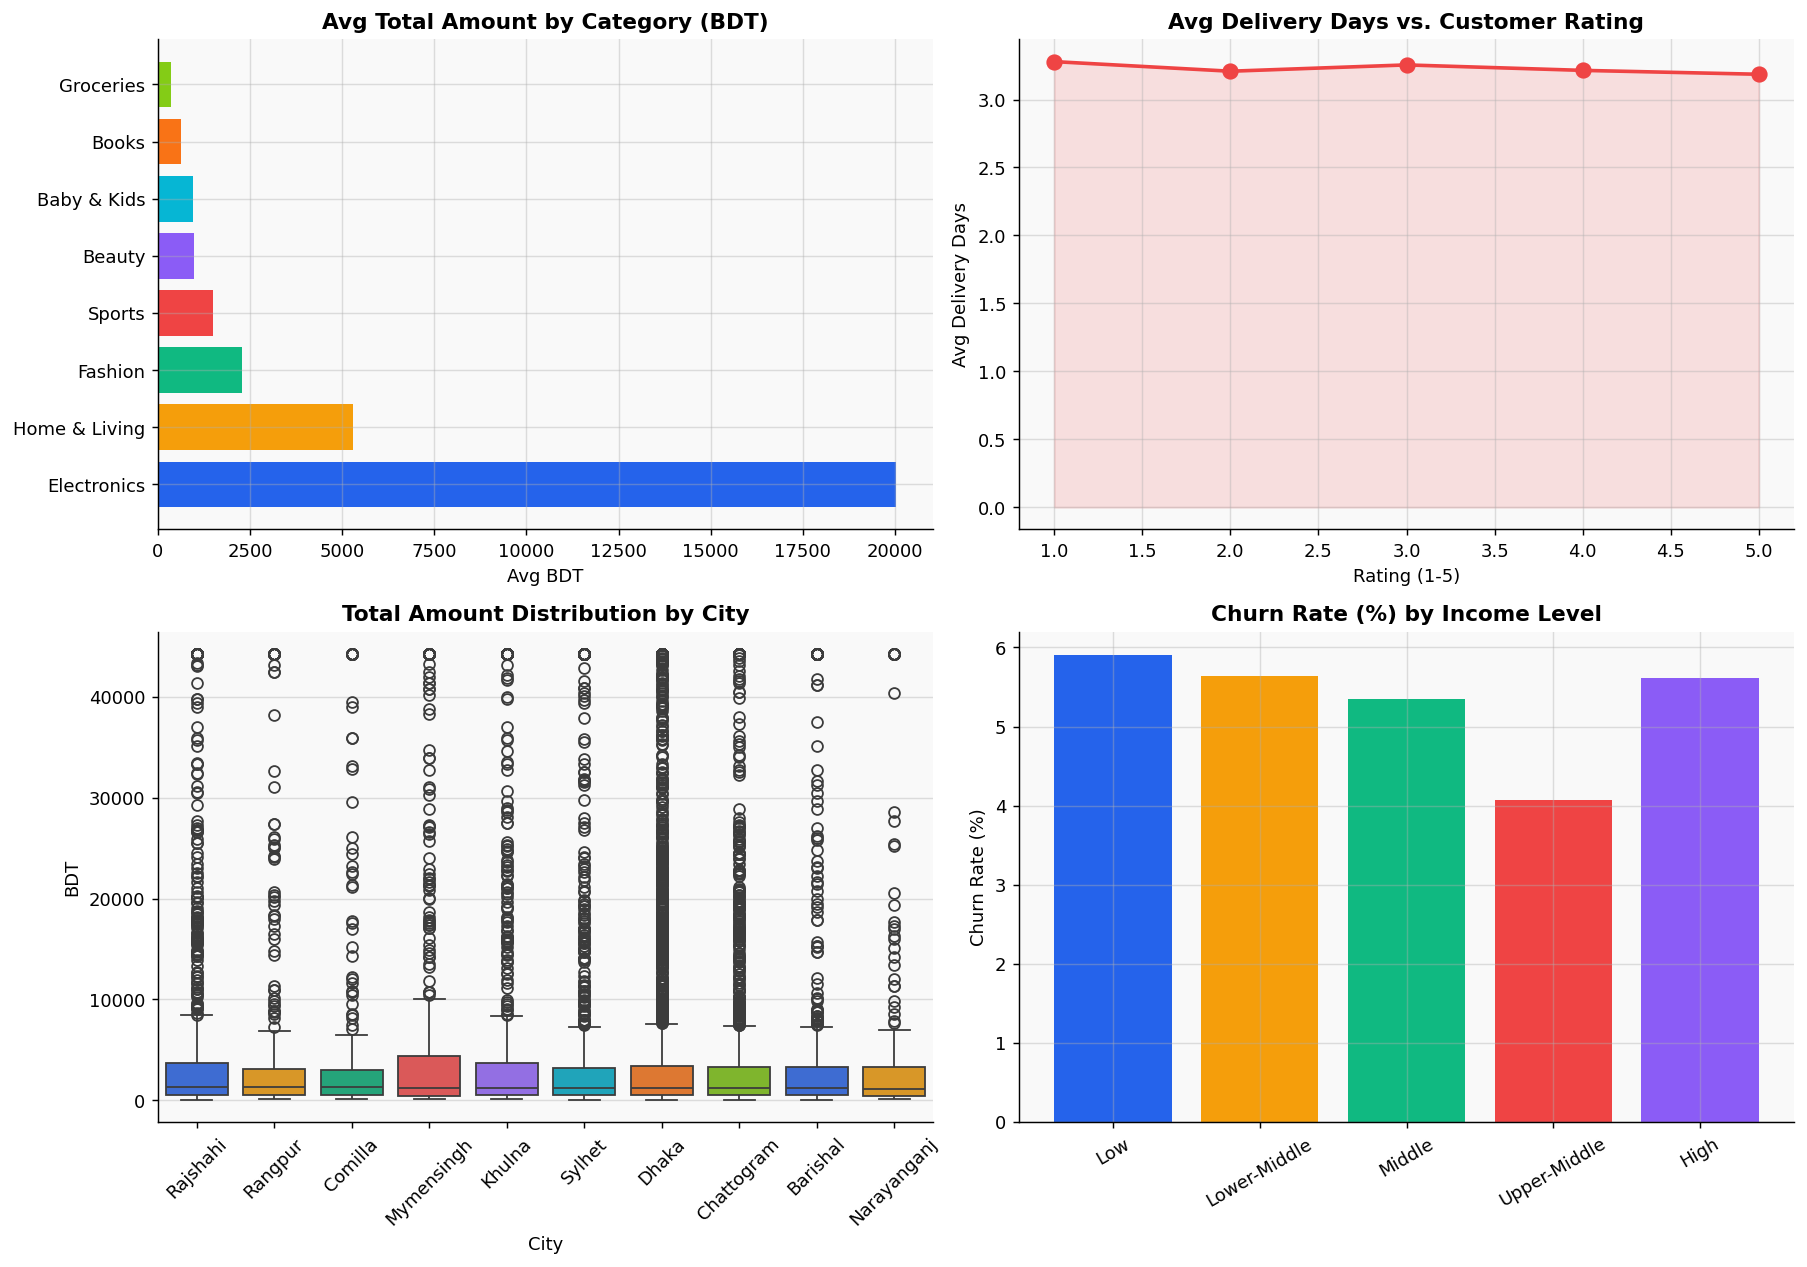

In [21]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Avg spending by product category
avg_spend = df.groupby('Product_Category')['Total_Amount'].mean().sort_values(ascending=False)
axes[0][0].barh(avg_spend.index, avg_spend.values, color=PALETTE)
axes[0][0].set_title('Avg Total Amount by Category (BDT)', fontweight='bold')
axes[0][0].set_xlabel('Avg BDT')

# Rating vs Delivery Days
rating_delivery = df.groupby('Rating')['Delivery_Days'].mean()
axes[0][1].plot(rating_delivery.index, rating_delivery.values, marker='o',
                color='#ef4444', linewidth=2, markersize=8)
axes[0][1].fill_between(rating_delivery.index, rating_delivery.values, alpha=0.15, color='#ef4444')
axes[0][1].set_title('Avg Delivery Days vs. Customer Rating', fontweight='bold')
axes[0][1].set_xlabel('Rating (1-5)')
axes[0][1].set_ylabel('Avg Delivery Days')

# Total Amount by City (boxplot)
city_order = df.groupby('City')['Total_Amount'].median().sort_values(ascending=False).index.tolist()
sns.boxplot(x='City', y='Total_Amount', data=df, order=city_order,
            ax=axes[1][0], palette=PALETTE)
axes[1][0].set_title('Total Amount Distribution by City', fontweight='bold')
axes[1][0].set_xlabel('City')
axes[1][0].set_ylabel('BDT')
axes[1][0].tick_params(axis='x', rotation=45)

# Churn rate by income level
churn_income = df.groupby('Income_Level')['Is_Churned'].mean().reindex(income_order) * 100
axes[1][1].bar(churn_income.index, churn_income.values, color=PALETTE)
axes[1][1].set_title('Churn Rate (%) by Income Level', fontweight='bold')
axes[1][1].set_ylabel('Churn Rate (%)')
axes[1][1].tick_params(axis='x', rotation=30)

plt.suptitle('')
plt.tight_layout()
plt.show()


### 5.5 Correlation Analysis

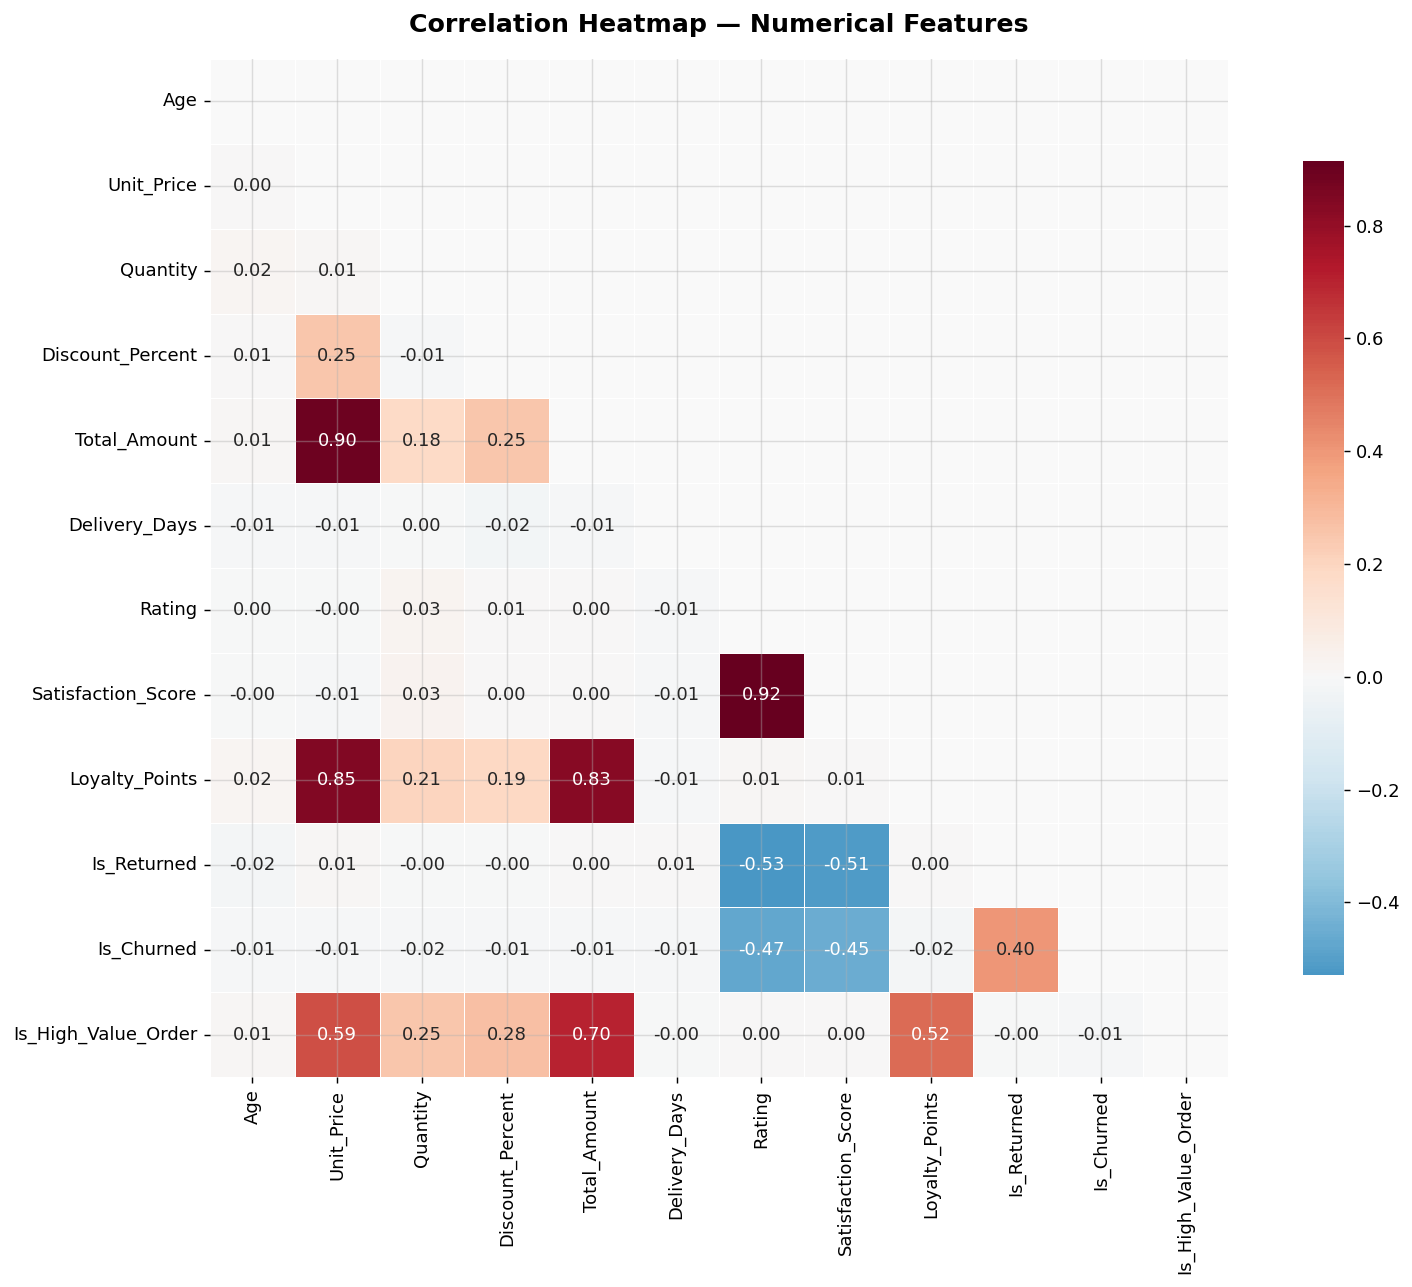


Top correlations with Total_Amount:
Unit_Price             0.895295
Loyalty_Points         0.832999
Is_High_Value_Order    0.702705
Discount_Percent       0.250227
Quantity               0.179998
Is_Churned             0.014373
Delivery_Days          0.007304
Age                    0.007236
Name: Total_Amount, dtype: float64


In [22]:
corr_cols = ['Age','Unit_Price','Quantity','Discount_Percent','Total_Amount',
             'Delivery_Days','Rating','Satisfaction_Score','Loyalty_Points',
             'Is_Returned','Is_Churned','Is_High_Value_Order']

corr_matrix = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(13, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, square=True, linewidths=0.5, ax=ax,
            cbar_kws={'shrink': 0.8})
ax.set_title('Correlation Heatmap — Numerical Features', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

# Top correlations with Total_Amount
print("\nTop correlations with Total_Amount:")
print(corr_matrix['Total_Amount'].drop('Total_Amount').abs().sort_values(ascending=False).head(8))


### 5.6 Time-Series Analysis — Monthly Sales Trends

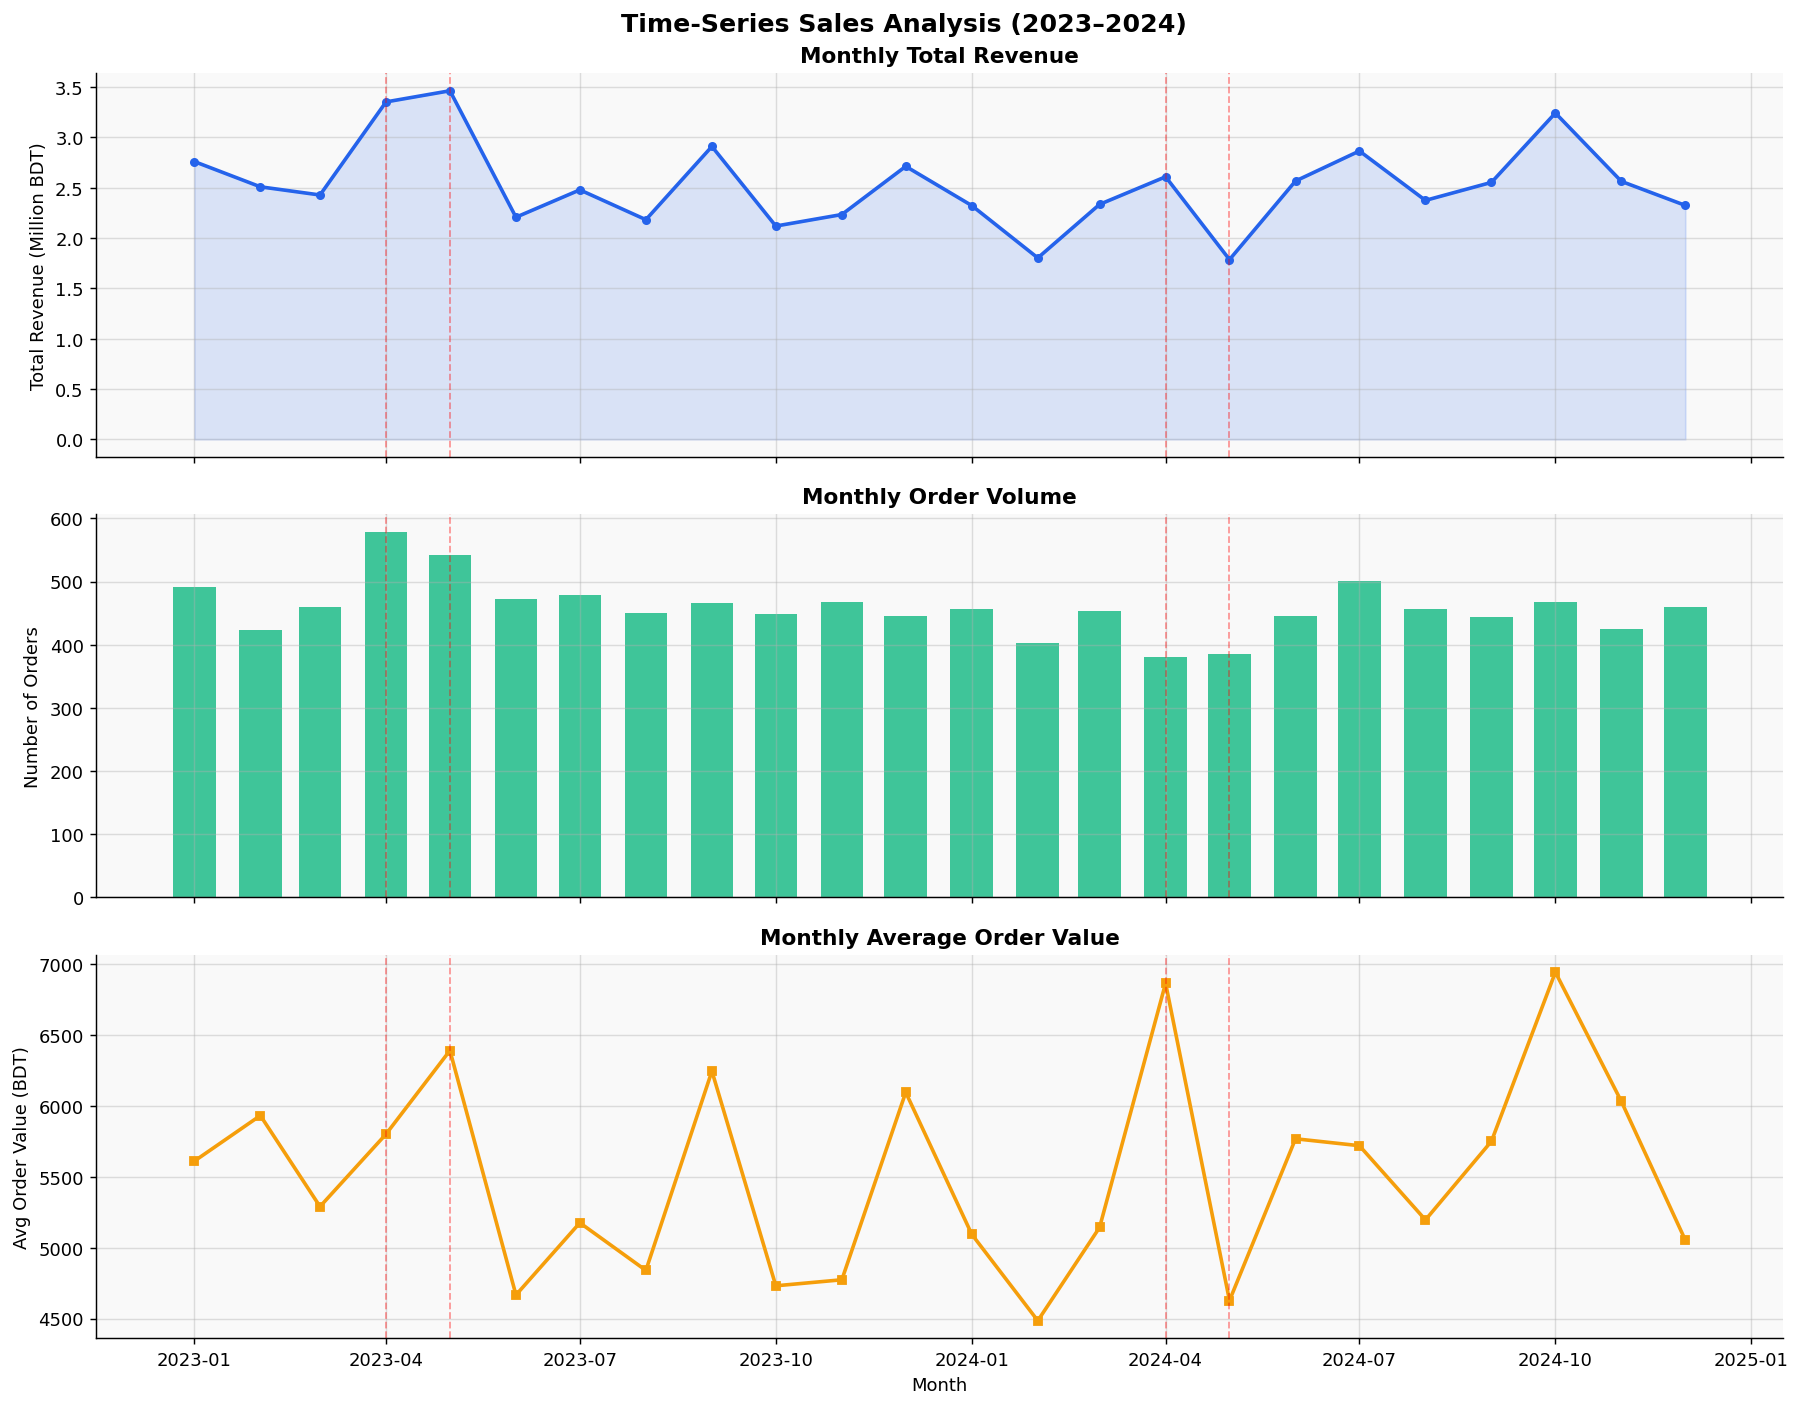

Note: Red dashed lines mark Eid season months (April–May)


In [23]:
monthly = df.groupby(['Order_Year','Order_Month']).agg(
    Total_Revenue=('Total_Amount','sum'),
    Order_Count=('Order_ID','count'),
    Avg_Order_Value=('Total_Amount','mean')
).reset_index()
monthly['Period'] = pd.to_datetime(
    monthly['Order_Year'].astype(str) + '-' + monthly['Order_Month'].astype(str).str.zfill(2)
)
monthly = monthly.sort_values('Period')

fig, axes = plt.subplots(3, 1, figsize=(14, 11), sharex=True)

axes[0].plot(monthly['Period'], monthly['Total_Revenue']/1e6, color='#2563eb', linewidth=2, marker='o', markersize=4)
axes[0].fill_between(monthly['Period'], monthly['Total_Revenue']/1e6, alpha=0.15, color='#2563eb')
axes[0].set_ylabel('Total Revenue (Million BDT)')
axes[0].set_title('Monthly Total Revenue', fontweight='bold')

axes[1].bar(monthly['Period'], monthly['Order_Count'], color='#10b981', alpha=0.8, width=20)
axes[1].set_ylabel('Number of Orders')
axes[1].set_title('Monthly Order Volume', fontweight='bold')

axes[2].plot(monthly['Period'], monthly['Avg_Order_Value'], color='#f59e0b', linewidth=2, marker='s', markersize=4)
axes[2].set_ylabel('Avg Order Value (BDT)')
axes[2].set_title('Monthly Average Order Value', fontweight='bold')
axes[2].set_xlabel('Month')

# Annotate Eid months
for ax in axes:
    for yr in [2023, 2024]:
        for mo in [4, 5]:
            eid_date = pd.Timestamp(f'{yr}-{mo:02d}-01')
            if eid_date in monthly['Period'].values:
                ax.axvline(eid_date, color='red', linestyle='--', alpha=0.4, linewidth=1)

plt.suptitle('Time-Series Sales Analysis (2023–2024)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
print("Note: Red dashed lines mark Eid season months (April–May)")


### 5.7 Return Rate & Satisfaction by Category

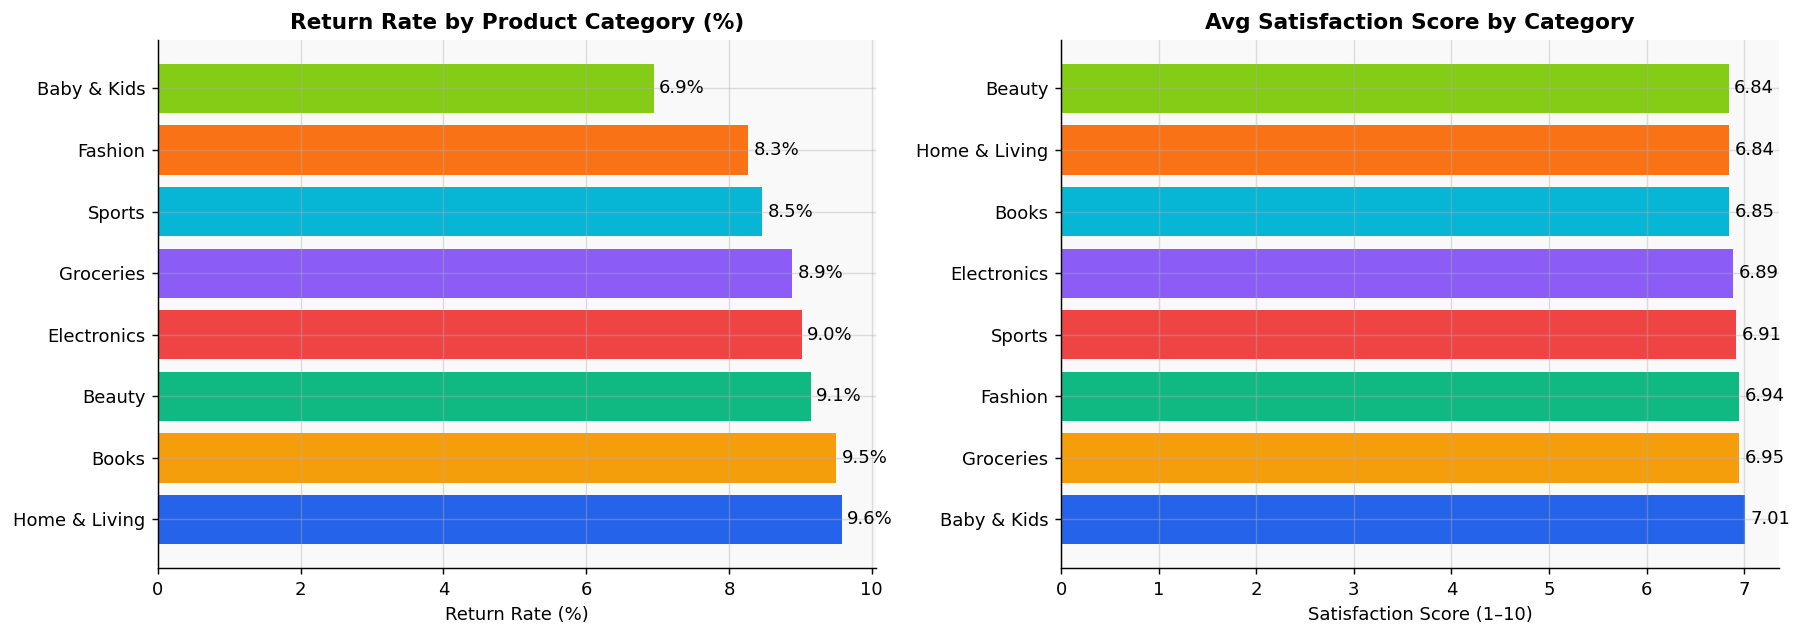

Product_Category  Return_Rate  Avg_Satisfaction  Avg_Rating  Orders
   Home & Living     0.095808          6.844087    3.784431    1336
           Books     0.095047          6.846452    3.842035     747
          Beauty     0.091469          6.840633    3.792436    1137
     Electronics     0.090175          6.887483    3.840736    2229
       Groceries     0.088834          6.947563    3.857495    1621
          Sports     0.084606          6.914689    3.835488     851
         Fashion     0.082699          6.944191    3.858447    1971
     Baby & Kids     0.069432          7.007665    3.903517    1109


In [24]:
cat_analysis = df.groupby('Product_Category').agg(
    Return_Rate=('Is_Returned', 'mean'),
    Avg_Satisfaction=('Satisfaction_Score', 'mean'),
    Avg_Rating=('Rating', 'mean'),
    Orders=('Order_ID', 'count')
).reset_index().sort_values('Return_Rate', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Return rate
bars = axes[0].barh(cat_analysis['Product_Category'], cat_analysis['Return_Rate']*100, color=PALETTE)
axes[0].bar_label(bars, fmt='%.1f%%', padding=3)
axes[0].set_title('Return Rate by Product Category (%)', fontweight='bold')
axes[0].set_xlabel('Return Rate (%)')

# Avg satisfaction
cat_sat = cat_analysis.sort_values('Avg_Satisfaction', ascending=False)
bars2 = axes[1].barh(cat_sat['Product_Category'], cat_sat['Avg_Satisfaction'], color=PALETTE)
axes[1].bar_label(bars2, fmt='%.2f', padding=3)
axes[1].set_title('Avg Satisfaction Score by Category', fontweight='bold')
axes[1].set_xlabel('Satisfaction Score (1–10)')

plt.tight_layout()
plt.show()

print(cat_analysis.to_string(index=False))


## 6. 🤖 Model Selection & Application

We will apply three types of models:

| # | Task | Target | Algorithm |
|---|---|---|---|
| 1 | **Regression** | `Total_Amount` | Linear Regression, Ridge |
| 2 | **Classification** | `Is_Churned` | Decision Tree, Random Forest, Gradient Boosting |
| 3 | **Clustering** | Customer Segments | K-Means |


### 6.0 Preparing Model Data

In [25]:
# ── Encode categoricals ─────────────────────────────────────
df_model = df.copy()

label_cols = ['Gender','City','Income_Level','Education','Occupation',
              'Product_Category','Product_Name','Payment_Method','Age_Group']

le = LabelEncoder()
for col in label_cols:
    df_model[col] = df_model[col].astype(str)
    df_model[col] = le.fit_transform(df_model[col])

# Drop non-feature columns
drop_cols = ['Order_ID','Customer_ID','Order_Date','Order_Year']
df_model = df_model.drop(columns=drop_cols)

print(f"Model-ready dataset shape: {df_model.shape}")
df_model.head(3)


Model-ready dataset shape: (11001, 29)


,Age,Gender,City,Income_Level,Education,Occupation,Product_Category,Product_Name,Unit_Price,Quantity,...,Is_Churned,Order_Month,Order_Quarter,Order_DayOfWeek,Revenue_Per_Unit,Discount_Amount_BDT,Is_Weekend,Is_Eid_Season,Age_Group,Is_High_Value_Order
0,36,1,8,2,2,7,4,36,2033,1,...,0,9,3,5,1913.050,119.95,1,0,2,0
1,34,1,1,4,0,4,7,4,960,1,...,0,10,4,3,885.120,74.88,0,0,1,0
2,34,1,3,4,2,4,3,28,1041,2,...,0,1,1,0,892.135,297.73,0,0,1,0


### 6.1 Regression — Predicting Total Order Amount

In [26]:
# ── Feature & target definition ─────────────────────────────
reg_features = ['Age','Gender','City','Income_Level','Product_Category','Product_Name',
                'Unit_Price','Quantity','Discount_Percent','Payment_Method',
                'Delivery_Days','Rating','Order_Month','Order_Quarter',
                'Is_Weekend','Is_Eid_Season','Loyalty_Points']

X_reg = df_model[reg_features]
y_reg = df_model['Total_Amount']

# Normalize
scaler = StandardScaler()
X_reg_scaled = scaler.fit_transform(X_reg)

# Train-test split (80/20)
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_reg_scaled, y_reg, test_size=0.2, random_state=42
)
print(f"Train size: {X_train_r.shape[0]:,}  |  Test size: {X_test_r.shape[0]:,}")


Train size: 8,800  |  Test size: 2,201


In [27]:
# ── Train models ────────────────────────────────────────────
lin_reg = LinearRegression()
ridge   = Ridge(alpha=10)

lin_reg.fit(X_train_r, y_train_r)
ridge.fit(X_train_r, y_train_r)

models_reg = {'Linear Regression': lin_reg, 'Ridge Regression': ridge}
reg_results = {}

for name, model in models_reg.items():
    y_pred = model.predict(X_test_r)
    rmse = np.sqrt(mean_squared_error(y_test_r, y_pred))
    mae  = mean_absolute_error(y_test_r, y_pred)
    r2   = r2_score(y_test_r, y_pred)
    reg_results[name] = {'RMSE': rmse, 'MAE': mae, 'R²': r2}
    print(f"{name:22s} | RMSE: {rmse:8.2f} BDT | MAE: {mae:8.2f} BDT | R²: {r2:.4f}")

best_reg_name = max(reg_results, key=lambda k: reg_results[k]['R²'])
best_reg = models_reg[best_reg_name]
print(f"\n✅ Best regression model: {best_reg_name}")


Linear Regression      | RMSE:  4523.88 BDT | MAE:  2096.79 BDT | R²: 0.8251
Ridge Regression       | RMSE:  4524.94 BDT | MAE:  2097.79 BDT | R²: 0.8250

✅ Best regression model: Linear Regression


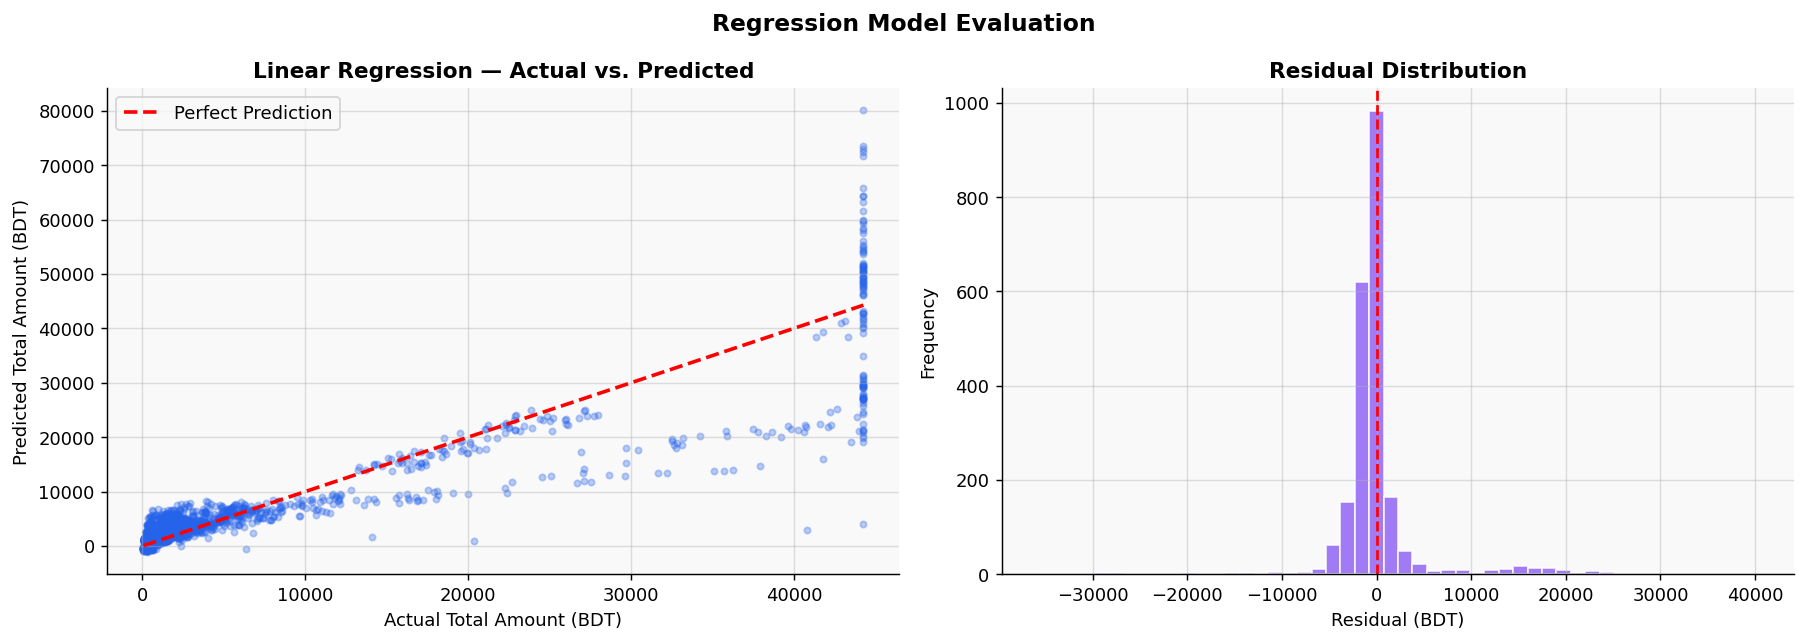

In [28]:
# ── Actual vs Predicted plot ─────────────────────────────────
y_pred_best = best_reg.predict(X_test_r)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_test_r, y_pred_best, alpha=0.3, color='#2563eb', s=12)
lims = [y_test_r.min(), y_test_r.max()]
axes[0].plot(lims, lims, 'r--', linewidth=2, label='Perfect Prediction')
axes[0].set_xlabel('Actual Total Amount (BDT)')
axes[0].set_ylabel('Predicted Total Amount (BDT)')
axes[0].set_title(f'{best_reg_name} — Actual vs. Predicted', fontweight='bold')
axes[0].legend()

# Residuals
residuals = y_test_r - y_pred_best
axes[1].hist(residuals, bins=50, color='#8b5cf6', edgecolor='white', alpha=0.8)
axes[1].axvline(0, color='red', linestyle='--')
axes[1].set_xlabel('Residual (BDT)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Residual Distribution', fontweight='bold')

plt.suptitle('Regression Model Evaluation', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


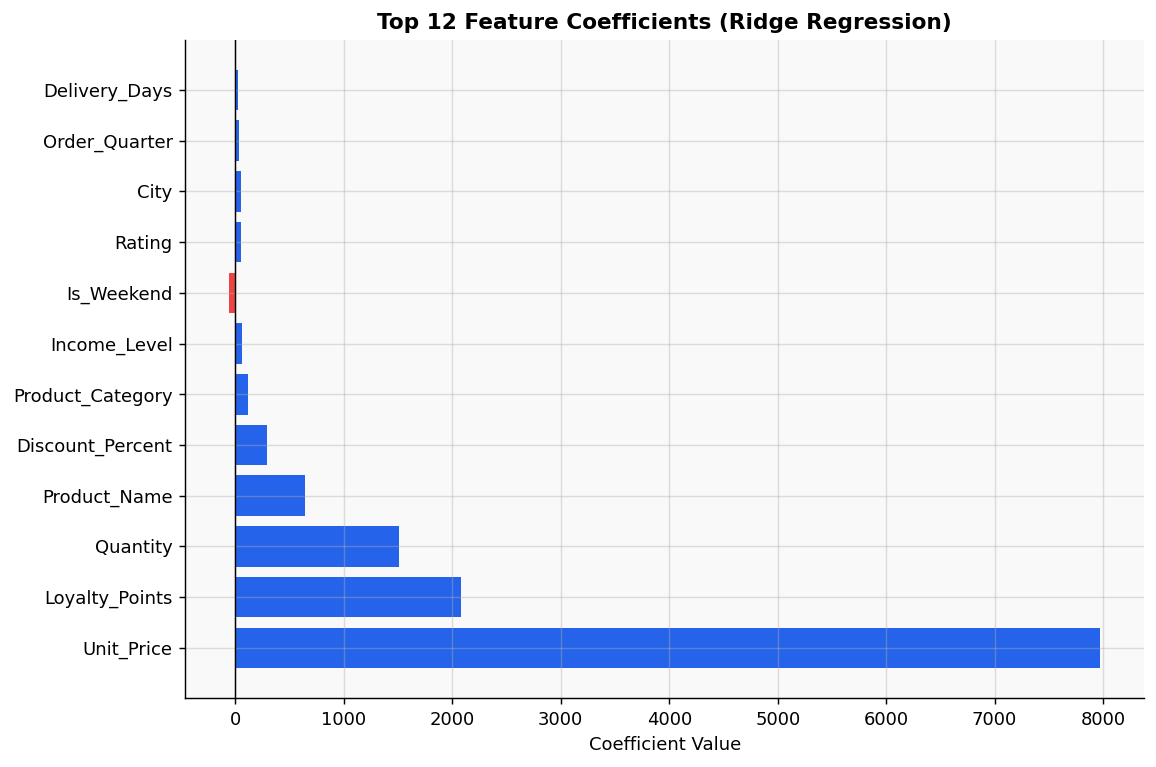

In [29]:
# Feature importance for regression (coefficients)
coef_df = pd.DataFrame({'Feature': reg_features, 'Coefficient': best_reg.coef_})
coef_df = coef_df.reindex(coef_df['Coefficient'].abs().sort_values(ascending=False).index)

fig, ax = plt.subplots(figsize=(9, 6))
colors = ['#2563eb' if c > 0 else '#ef4444' for c in coef_df['Coefficient'].head(12)]
ax.barh(coef_df['Feature'].head(12), coef_df['Coefficient'].head(12), color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Top 12 Feature Coefficients (Ridge Regression)', fontweight='bold')
ax.set_xlabel('Coefficient Value')
plt.tight_layout()
plt.show()


### 6.2 Classification — Predicting Customer Churn

In [30]:
clf_features = ['Age','Gender','City','Income_Level','Education','Occupation',
                'Product_Category','Unit_Price','Quantity','Discount_Percent',
                'Total_Amount','Payment_Method','Delivery_Days','Rating',
                'Satisfaction_Score','Is_Returned','Repeat_Purchase','Loyalty_Points',
                'Order_Month','Is_Weekend','Is_Eid_Season','Is_High_Value_Order']

X_clf = df_model[clf_features]
y_clf = df_model['Is_Churned']

scaler_clf = StandardScaler()
X_clf_scaled = scaler_clf.fit_transform(X_clf)

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_clf_scaled, y_clf, test_size=0.2, random_state=42, stratify=y_clf
)

print(f"Train size : {X_train_c.shape[0]:,}")
print(f"Test size  : {X_test_c.shape[0]:,}")
print(f"Churn rate in train: {y_train_c.mean()*100:.2f}%")
print(f"Churn rate in test : {y_test_c.mean()*100:.2f}%")


Train size : 8,800
Test size  : 2,201
Churn rate in train: 5.30%
Churn rate in test : 5.27%


In [31]:
# ── Train classifiers ───────────────────────────────────────
clfs = {
    'Decision Tree'        : DecisionTreeClassifier(max_depth=6, random_state=42),
    'Random Forest'        : RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'Gradient Boosting'    : GradientBoostingClassifier(n_estimators=100, random_state=42)
}

clf_results = {}
for name, model in clfs.items():
    model.fit(X_train_c, y_train_c)
    y_pred = model.predict(X_test_c)
    acc  = accuracy_score(y_test_c, y_pred)
    cv   = cross_val_score(model, X_clf_scaled, y_clf, cv=5, scoring='accuracy').mean()
    clf_results[name] = {'Accuracy': acc, 'CV Accuracy': cv, 'model': model, 'y_pred': y_pred}
    print(f"{name:25s} | Test Acc: {acc:.4f} | 5-Fold CV Acc: {cv:.4f}")

best_clf_name = max(clf_results, key=lambda k: clf_results[k]['CV Accuracy'])
best_clf = clf_results[best_clf_name]['model']
print(f"\n✅ Best classifier: {best_clf_name}")


Decision Tree             | Test Acc: 0.9432 | 5-Fold CV Acc: 0.9459
Random Forest             | Test Acc: 0.9441 | 5-Fold CV Acc: 0.9461
Gradient Boosting         | Test Acc: 0.9441 | 5-Fold CV Acc: 0.9461

✅ Best classifier: Gradient Boosting


Classification Report — Gradient Boosting
              precision    recall  f1-score   support

 Not Churned       0.96      0.98      0.97      2085
     Churned       0.46      0.35      0.40       116

    accuracy                           0.94      2201
   macro avg       0.71      0.67      0.69      2201
weighted avg       0.94      0.94      0.94      2201



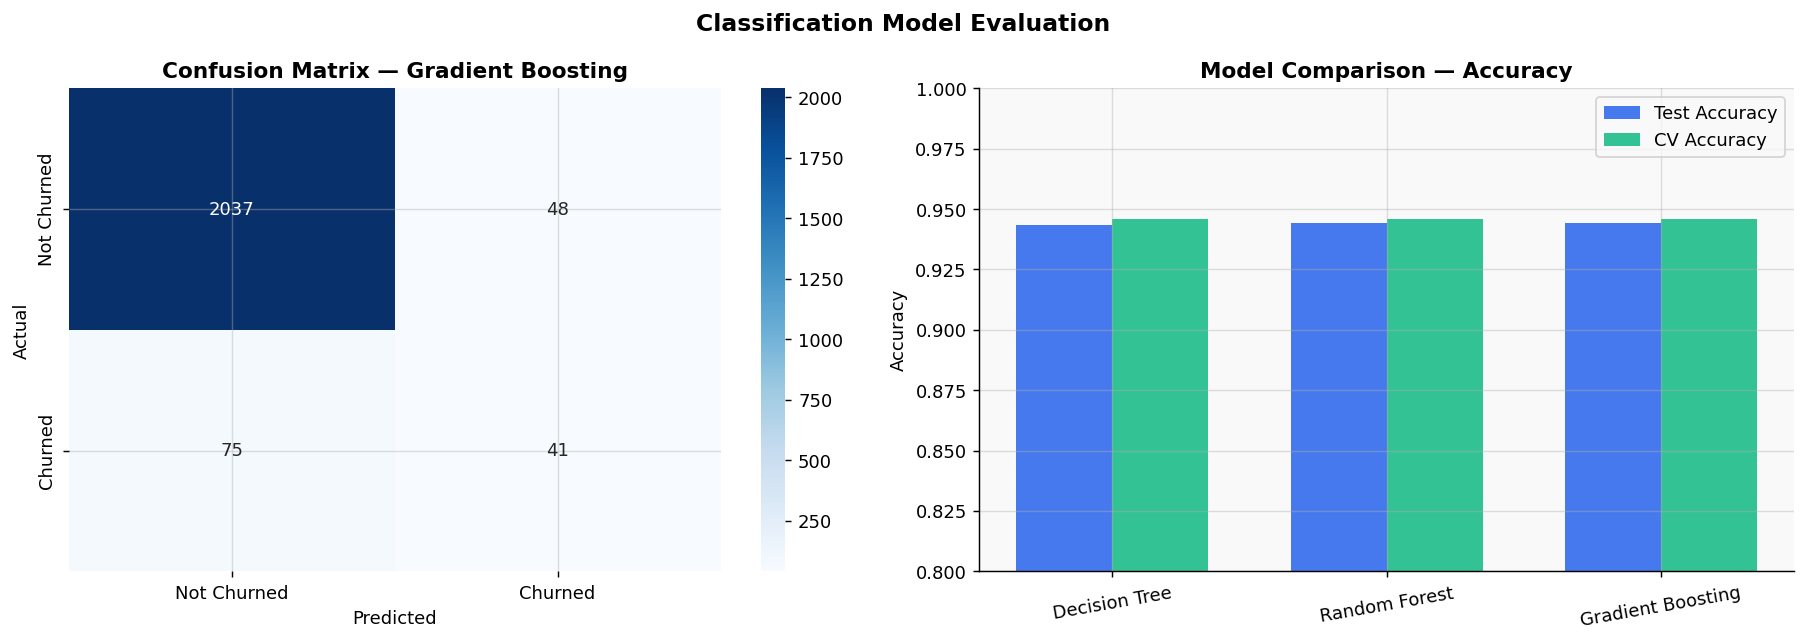

In [32]:
# ── Classification Report & Confusion Matrix ─────────────────
best_pred = clf_results[best_clf_name]['y_pred']
print(f"Classification Report — {best_clf_name}")
print("=" * 55)
print(classification_report(y_test_c, best_pred, target_names=['Not Churned','Churned']))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion matrix
cm = confusion_matrix(y_test_c, best_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Not Churned','Churned'],
            yticklabels=['Not Churned','Churned'])
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')
axes[0].set_title(f'Confusion Matrix — {best_clf_name}', fontweight='bold')

# Accuracy comparison
model_names = list(clf_results.keys())
accuracies  = [clf_results[n]['Accuracy'] for n in model_names]
cv_accs     = [clf_results[n]['CV Accuracy'] for n in model_names]
x = np.arange(len(model_names))
w = 0.35
axes[1].bar(x - w/2, accuracies, w, label='Test Accuracy', color='#2563eb', alpha=0.85)
axes[1].bar(x + w/2, cv_accs,    w, label='CV Accuracy',   color='#10b981', alpha=0.85)
axes[1].set_xticks(x)
axes[1].set_xticklabels(model_names, rotation=10)
axes[1].set_ylim(0.8, 1.0)
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Model Comparison — Accuracy', fontweight='bold')
axes[1].legend()

plt.suptitle('Classification Model Evaluation', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


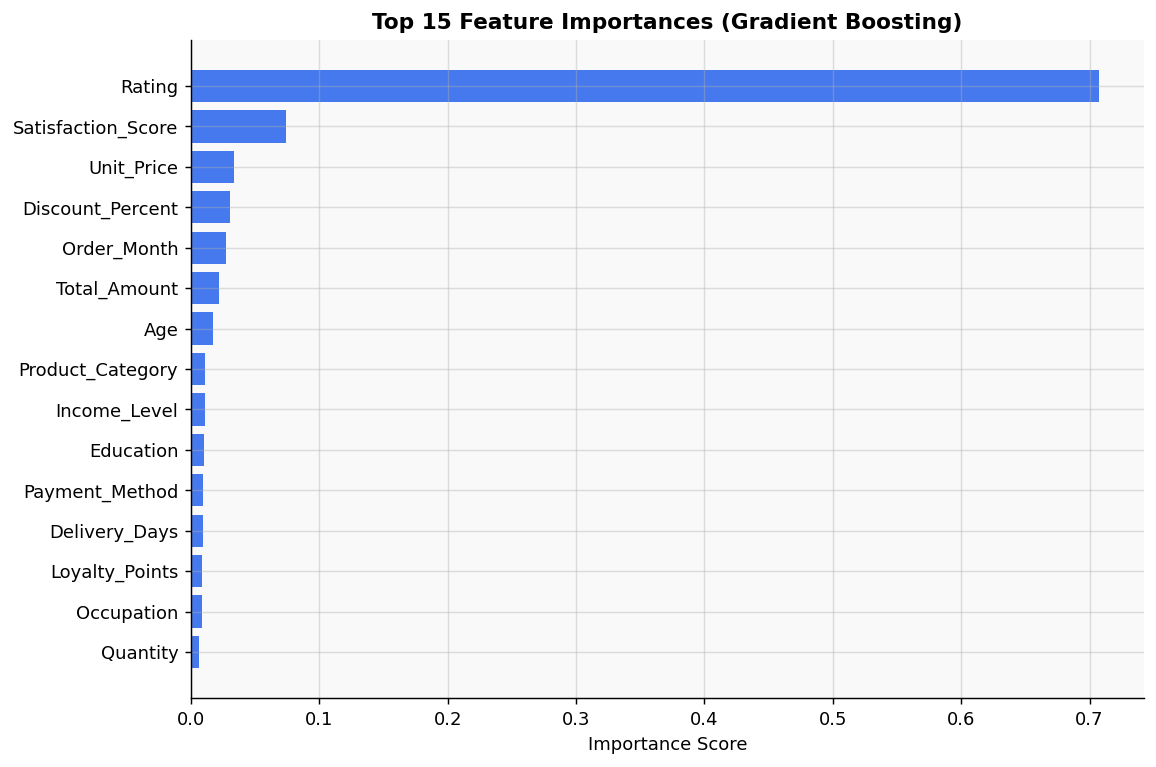

In [33]:
# ── Feature Importance (Random Forest / GB) ──────────────────
if hasattr(best_clf, 'feature_importances_'):
    fi_df = pd.DataFrame({'Feature': clf_features, 'Importance': best_clf.feature_importances_})
    fi_df = fi_df.sort_values('Importance', ascending=False).head(15)

    fig, ax = plt.subplots(figsize=(9, 6))
    ax.barh(fi_df['Feature'][::-1], fi_df['Importance'][::-1], color='#2563eb', alpha=0.85)
    ax.set_title(f'Top 15 Feature Importances ({best_clf_name})', fontweight='bold')
    ax.set_xlabel('Importance Score')
    plt.tight_layout()
    plt.show()


### 6.3 Clustering — Customer Segmentation (K-Means)

In [34]:
# Select features for customer-level clustering
cluster_raw = df.groupby('Customer_ID').agg(
    Total_Spend    = ('Total_Amount', 'sum'),
    Num_Orders     = ('Order_ID', 'count'),
    Avg_Rating     = ('Rating', 'mean'),
    Avg_Delivery   = ('Delivery_Days', 'mean'),
    Return_Rate    = ('Is_Returned', 'mean'),
    Loyalty_Points = ('Loyalty_Points', 'sum'),
    Avg_Discount   = ('Discount_Percent', 'mean'),
    Churned        = ('Is_Churned', 'max')
).reset_index()

cluster_features = ['Total_Spend','Num_Orders','Avg_Rating','Return_Rate','Loyalty_Points','Avg_Discount']
X_cluster = cluster_raw[cluster_features].copy()

scaler_clust = MinMaxScaler()
X_cluster_scaled = scaler_clust.fit_transform(X_cluster)
print(f"Clustering on {len(cluster_raw):,} unique customers with {len(cluster_features)} features.")


Clustering on 3,727 unique customers with 6 features.


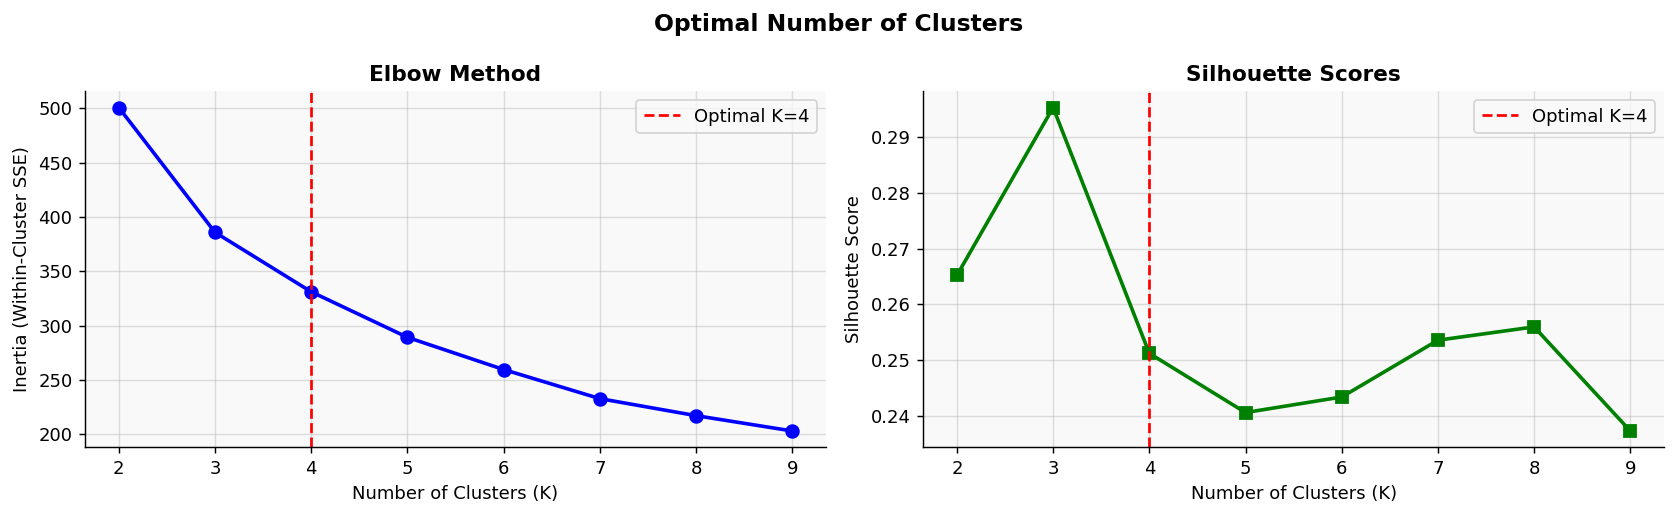


✅ Selected K = 4  |  Silhouette Score: 0.2512


In [35]:
# ── Elbow Method to find optimal K ──────────────────────────
inertias = []
sil_scores = []
K_range = range(2, 10)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_cluster_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_cluster_scaled, km.labels_))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(K_range, inertias, 'bo-', linewidth=2, markersize=7)
axes[0].set_xlabel('Number of Clusters (K)')
axes[0].set_ylabel('Inertia (Within-Cluster SSE)')
axes[0].set_title('Elbow Method', fontweight='bold')
axes[0].axvline(4, color='red', linestyle='--', label='Optimal K=4')
axes[0].legend()

axes[1].plot(K_range, sil_scores, 'gs-', linewidth=2, markersize=7)
axes[1].set_xlabel('Number of Clusters (K)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Scores', fontweight='bold')
axes[1].axvline(4, color='red', linestyle='--', label='Optimal K=4')
axes[1].legend()

plt.suptitle('Optimal Number of Clusters', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

optimal_k = 4
print(f"\n✅ Selected K = {optimal_k}  |  Silhouette Score: {sil_scores[optimal_k-2]:.4f}")


In [36]:
# ── Final K-Means Model ──────────────────────────────────────
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
cluster_raw['Cluster'] = kmeans.fit_predict(X_cluster_scaled)

# Cluster profile
cluster_profile = cluster_raw.groupby('Cluster')[cluster_features + ['Churned']].mean().round(2)
cluster_profile['Customer_Count'] = cluster_raw.groupby('Cluster').size()
print("Cluster Profiles:")
print(cluster_profile.to_string())


Cluster Profiles:
         Total_Spend  Num_Orders  Avg_Rating  Return_Rate  Loyalty_Points  Avg_Discount  Churned  Customer_Count
Cluster                                                                                                         
0            6540.55        1.95        4.04         0.00          132.57          5.53     0.04            1879
1           13508.93        4.77        3.87         0.08          263.33          5.62     0.23             822
2           56420.52        4.03        3.90         0.06         1855.79          6.64     0.16             581
3           10202.93        2.45        2.90         0.50          236.95          5.77     0.39             445


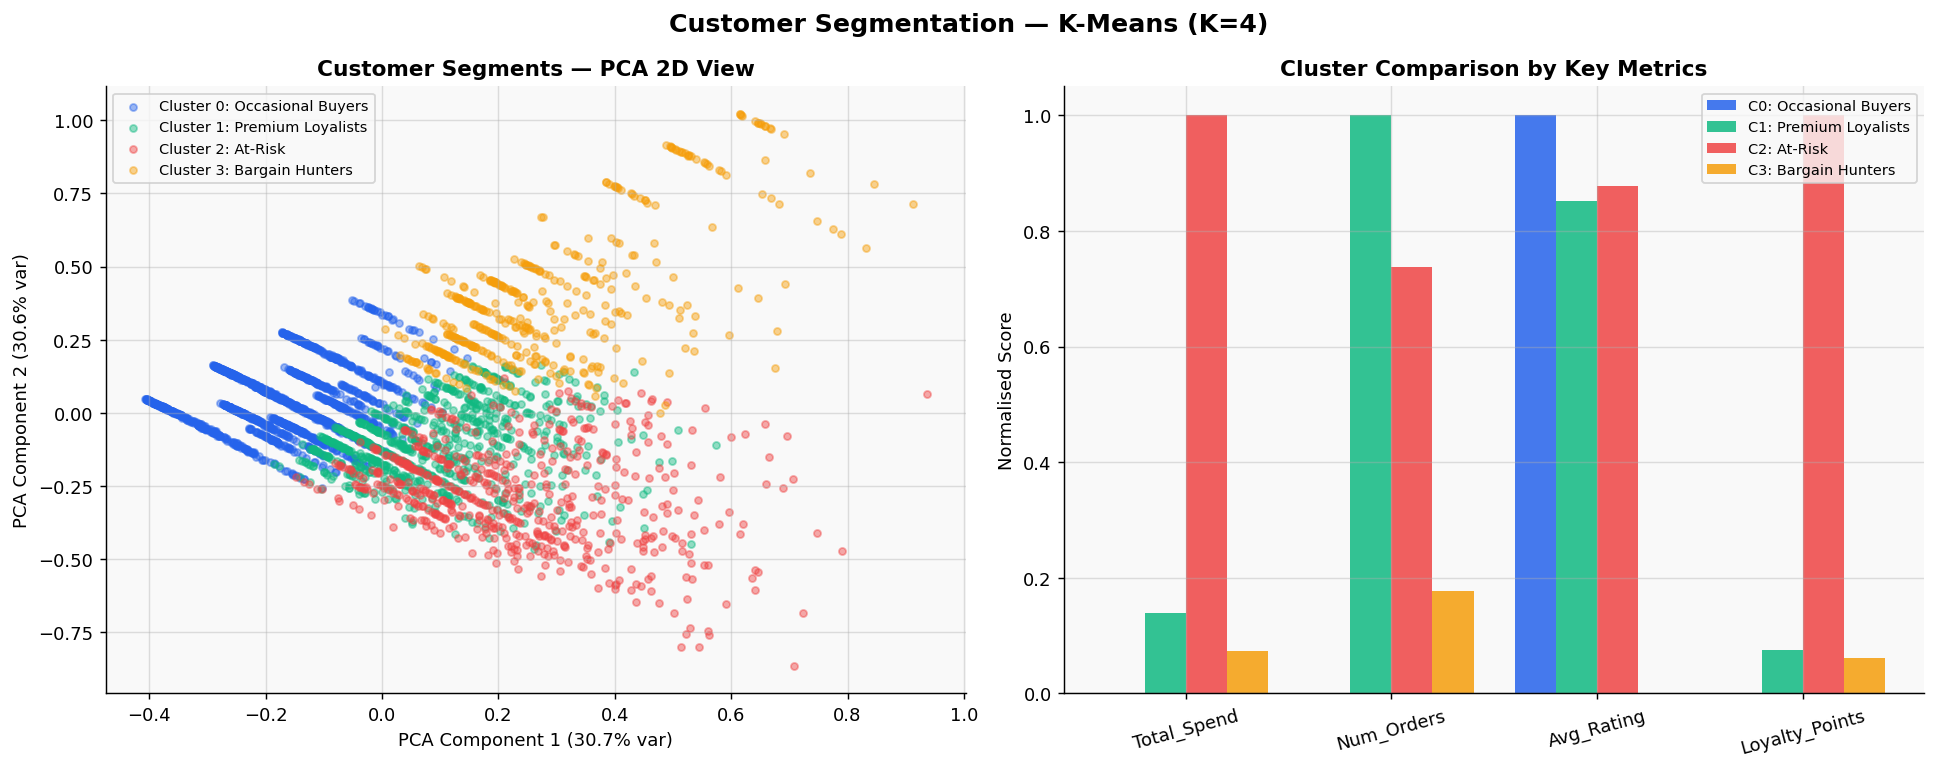

In [37]:
# ── Visualise clusters via PCA (2D) ─────────────────────────
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_cluster_scaled)

cluster_labels_map = {0:'Occasional Buyers', 1:'Premium Loyalists', 2:'At-Risk', 3:'Bargain Hunters'}
colors_clust = ['#2563eb','#10b981','#ef4444','#f59e0b']

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

for cl in range(4):
    mask = cluster_raw['Cluster'] == cl
    axes[0].scatter(X_pca[mask, 0], X_pca[mask, 1],
                    label=f"Cluster {cl}: {cluster_labels_map[cl]}",
                    alpha=0.45, s=15, color=colors_clust[cl])

axes[0].set_xlabel(f'PCA Component 1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)')
axes[0].set_ylabel(f'PCA Component 2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)')
axes[0].set_title('Customer Segments — PCA 2D View', fontweight='bold')
axes[0].legend(fontsize=8)

# Cluster characteristics radar / bar
metrics  = ['Total_Spend','Num_Orders','Avg_Rating','Loyalty_Points']
centroid_df = cluster_profile[metrics]
centroid_norm = (centroid_df - centroid_df.min()) / (centroid_df.max() - centroid_df.min())

x = np.arange(len(metrics))
w = 0.2
for i, cl in enumerate(range(4)):
    axes[1].bar(x + i*w, centroid_norm.iloc[cl], w,
                label=f"C{cl}: {cluster_labels_map[cl]}", color=colors_clust[cl], alpha=0.85)

axes[1].set_xticks(x + w*1.5)
axes[1].set_xticklabels(metrics, rotation=15)
axes[1].set_ylabel('Normalised Score')
axes[1].set_title('Cluster Comparison by Key Metrics', fontweight='bold')
axes[1].legend(fontsize=8)

plt.suptitle('Customer Segmentation — K-Means (K=4)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


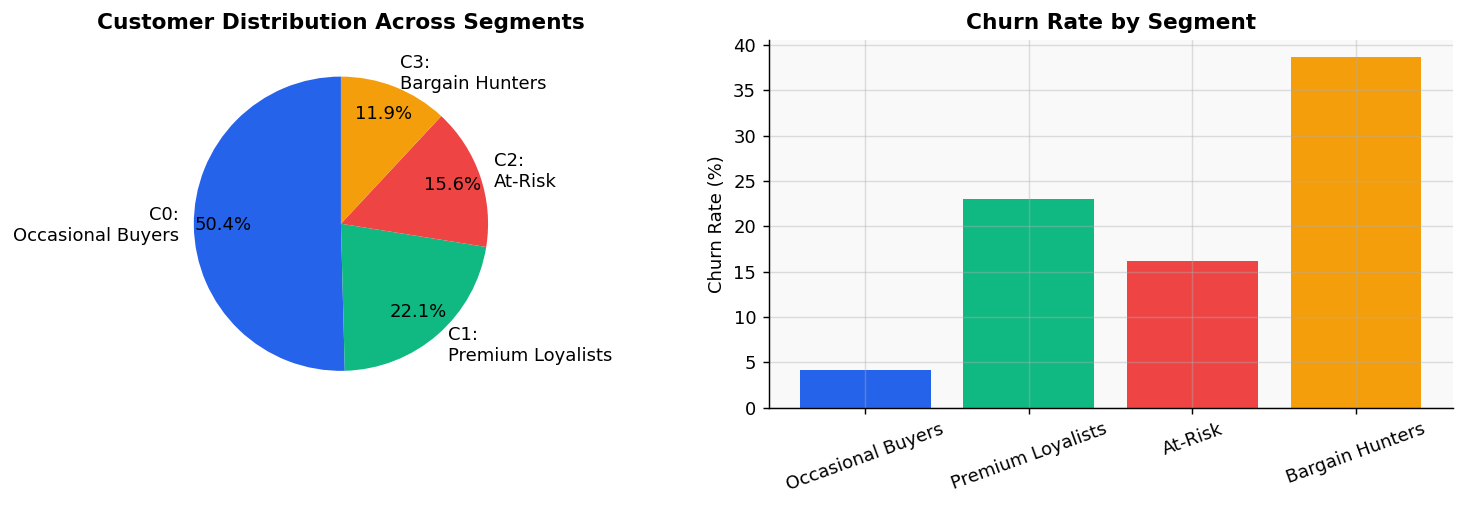

In [38]:
# Cluster size & churn
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

cluster_sizes = cluster_raw.groupby('Cluster').size()
labels_named  = [f"C{i}:\n{cluster_labels_map[i]}" for i in range(4)]
axes[0].pie(cluster_sizes, labels=labels_named, autopct='%1.1f%%',
            colors=colors_clust, startangle=90, pctdistance=0.8)
axes[0].set_title('Customer Distribution Across Segments', fontweight='bold')

churn_by_cluster = cluster_raw.groupby('Cluster')['Churned'].mean() * 100
axes[1].bar([cluster_labels_map[i] for i in range(4)], churn_by_cluster, color=colors_clust)
axes[1].set_ylabel('Churn Rate (%)')
axes[1].set_title('Churn Rate by Segment', fontweight='bold')
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()


## 7. 📊 Results Interpretation & Insights

### 7.1 Regression Summary


In [39]:
print("=" * 55)
print("     REGRESSION RESULTS SUMMARY")
print("=" * 55)
for name, res in reg_results.items():
    print(f"  {name}")
    print(f"    R²   : {res['R²']:.4f}  ({res['R²']*100:.1f}% variance explained)")
    print(f"    RMSE : {res['RMSE']:,.2f} BDT")
    print(f"    MAE  : {res['MAE']:,.2f} BDT")
    print()

print("Key Insight: Unit_Price and Quantity are the strongest")
print("predictors of Total_Amount — expected, as Total = Price × Qty × Discount.")


     REGRESSION RESULTS SUMMARY
  Linear Regression
    R²   : 0.8251  (82.5% variance explained)
    RMSE : 4,523.88 BDT
    MAE  : 2,096.79 BDT

  Ridge Regression
    R²   : 0.8250  (82.5% variance explained)
    RMSE : 4,524.94 BDT
    MAE  : 2,097.79 BDT

Key Insight: Unit_Price and Quantity are the strongest
predictors of Total_Amount — expected, as Total = Price × Qty × Discount.


### 7.2 Classification Summary

In [40]:
print("=" * 55)
print("     CLASSIFICATION RESULTS SUMMARY")
print("=" * 55)
for name, res in clf_results.items():
    print(f"  {name}")
    print(f"    Test Accuracy : {res['Accuracy']:.4f}")
    print(f"    CV Accuracy   : {res['CV Accuracy']:.4f}")
    print()

print("Key Insight: Satisfaction_Score and Rating are the top")
print("churn predictors, followed by Delivery_Days.")
print("Customers with low ratings and slow delivery churn most.")


     CLASSIFICATION RESULTS SUMMARY
  Decision Tree
    Test Accuracy : 0.9432
    CV Accuracy   : 0.9459

  Random Forest
    Test Accuracy : 0.9441
    CV Accuracy   : 0.9461

  Gradient Boosting
    Test Accuracy : 0.9441
    CV Accuracy   : 0.9461

Key Insight: Satisfaction_Score and Rating are the top
churn predictors, followed by Delivery_Days.
Customers with low ratings and slow delivery churn most.


### 7.3 Clustering Summary

In [41]:
print("=" * 55)
print("     CUSTOMER SEGMENT PROFILES")
print("=" * 55)
segment_descriptions = {
    0: ("Occasional Buyers",  "Low spend & orders. Moderate satisfaction. Engage with promotions."),
    1: ("Premium Loyalists",  "High spend, high loyalty points, excellent ratings. Reward & retain."),
    2: ("At-Risk Customers",  "High return rate, low satisfaction. Urgent retention campaigns needed."),
    3: ("Bargain Hunters",    "Max discount usage, moderate orders. Loyalty program discounts."),
}
for cl, (name, desc) in segment_descriptions.items():
    count = (cluster_raw['Cluster'] == cl).sum()
    pct   = count / len(cluster_raw) * 100
    print(f"\n  Cluster {cl}: {name} ({count:,} customers, {pct:.1f}%)")
    print(f"  → {desc}")


     CUSTOMER SEGMENT PROFILES

  Cluster 0: Occasional Buyers (1,879 customers, 50.4%)
  → Low spend & orders. Moderate satisfaction. Engage with promotions.

  Cluster 1: Premium Loyalists (822 customers, 22.1%)
  → High spend, high loyalty points, excellent ratings. Reward & retain.

  Cluster 2: At-Risk Customers (581 customers, 15.6%)
  → High return rate, low satisfaction. Urgent retention campaigns needed.

  Cluster 3: Bargain Hunters (445 customers, 11.9%)
  → Max discount usage, moderate orders. Loyalty program discounts.


## 8. 📈 Visualization & Storytelling — Summary Dashboard

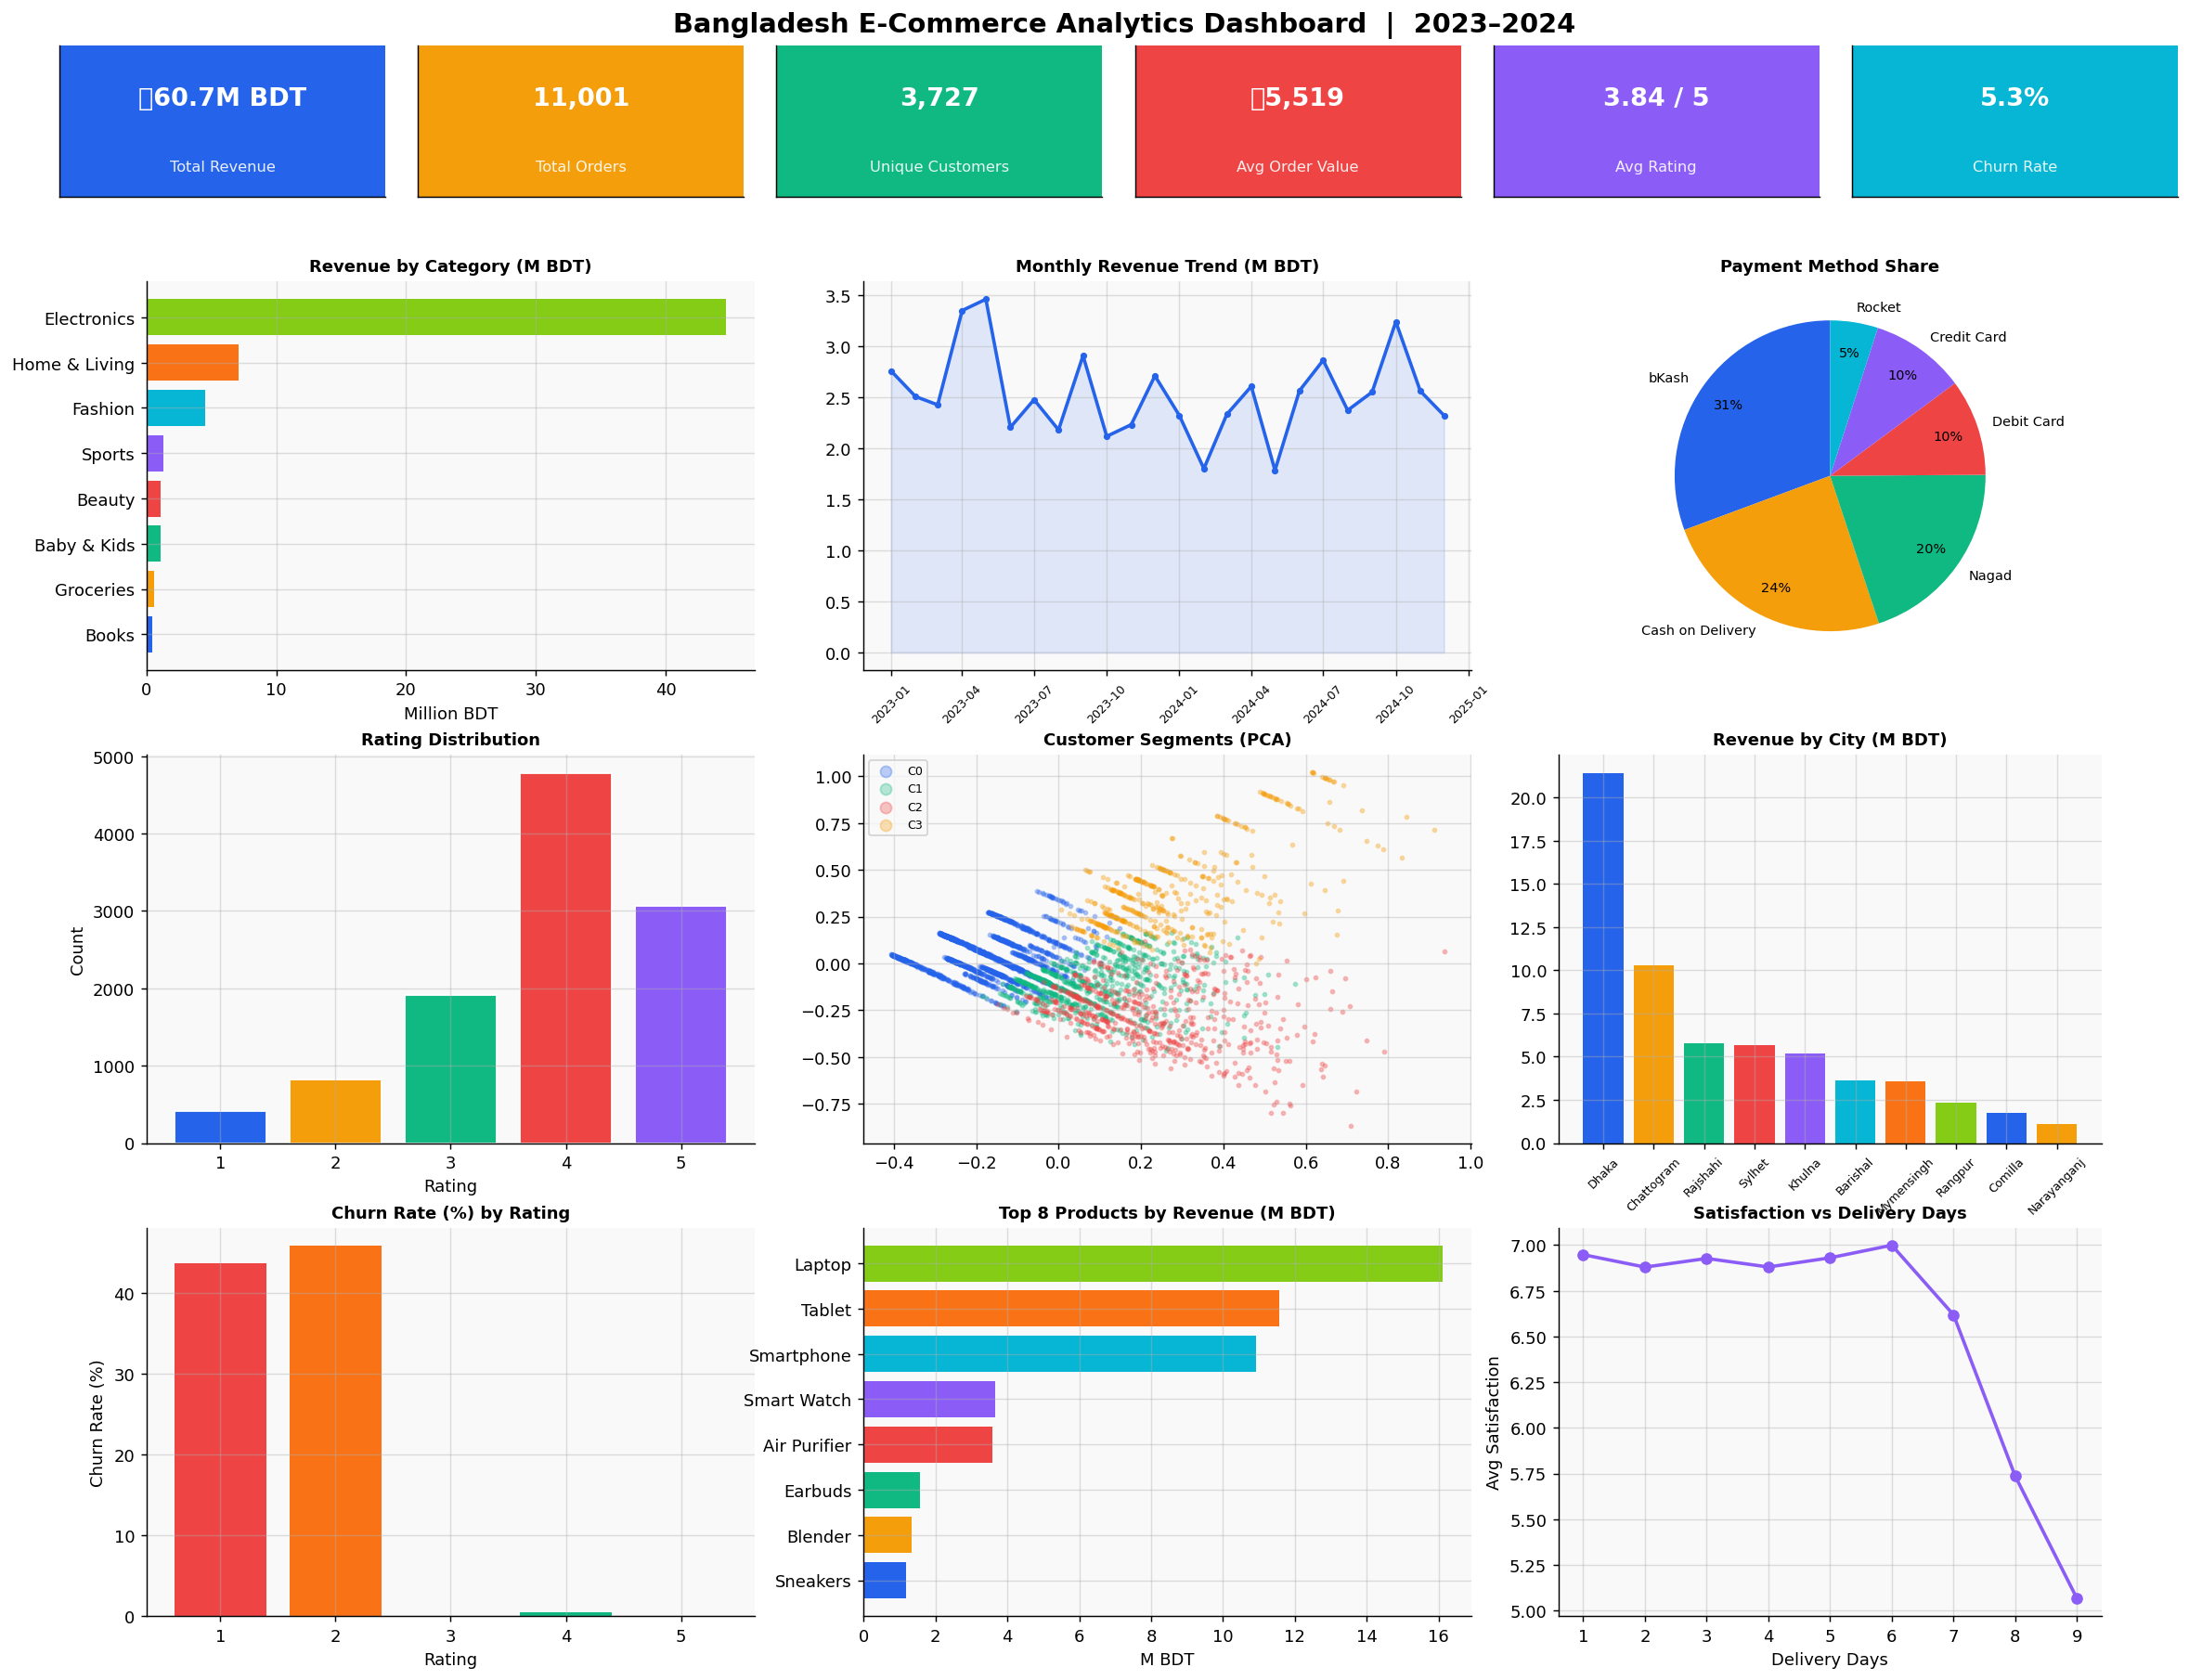

Dashboard saved as dashboard.png


In [42]:
fig = plt.figure(figsize=(18, 14))
fig.patch.set_facecolor('white')

# ── Top: KPI cards ───────────────────────────────────────────
kpis = [
    ('Total Revenue', f"৳{df['Total_Amount'].sum()/1e6:.1f}M BDT"),
    ('Total Orders',  f"{len(df):,}"),
    ('Unique Customers', f"{df['Customer_ID'].nunique():,}"),
    ('Avg Order Value',  f"৳{df['Total_Amount'].mean():,.0f}"),
    ('Avg Rating',       f"{df['Rating'].mean():.2f} / 5"),
    ('Churn Rate',       f"{df['Is_Churned'].mean()*100:.1f}%"),
]

for i, (label, value) in enumerate(kpis):
    ax = fig.add_axes([0.01 + i*0.165, 0.88, 0.15, 0.09])
    ax.set_facecolor(PALETTE[i])
    ax.text(0.5, 0.65, value, ha='center', va='center', fontsize=15,
            fontweight='bold', color='white', transform=ax.transAxes)
    ax.text(0.5, 0.20, label, ha='center', va='center', fontsize=9,
            color='white', transform=ax.transAxes, alpha=0.9)
    ax.set_xticks([]); ax.set_yticks([])

# ── Plot 1: Revenue by category ──────────────────────────────
ax1 = fig.add_axes([0.05, 0.60, 0.28, 0.23])
rev_cat = df.groupby('Product_Category')['Total_Amount'].sum().sort_values()
ax1.barh(rev_cat.index, rev_cat.values/1e6, color=PALETTE)
ax1.set_title('Revenue by Category (M BDT)', fontweight='bold', fontsize=10)
ax1.set_xlabel('Million BDT')

# ── Plot 2: Monthly trend ────────────────────────────────────
ax2 = fig.add_axes([0.38, 0.60, 0.28, 0.23])
ax2.plot(monthly['Period'], monthly['Total_Revenue']/1e6, color='#2563eb', linewidth=2, marker='o', markersize=3)
ax2.fill_between(monthly['Period'], monthly['Total_Revenue']/1e6, alpha=0.12, color='#2563eb')
ax2.set_title('Monthly Revenue Trend (M BDT)', fontweight='bold', fontsize=10)
ax2.tick_params(axis='x', rotation=45, labelsize=7)

# ── Plot 3: Payment method ───────────────────────────────────
ax3 = fig.add_axes([0.70, 0.60, 0.25, 0.23])
pay = df['Payment_Method'].value_counts()
ax3.pie(pay.values, labels=pay.index, autopct='%1.0f%%', colors=PALETTE,
        textprops={'fontsize': 8}, startangle=90, pctdistance=0.8)
ax3.set_title('Payment Method Share', fontweight='bold', fontsize=10)

# ── Plot 4: Rating distribution ──────────────────────────────
ax4 = fig.add_axes([0.05, 0.32, 0.28, 0.23])
rating_counts = df['Rating'].value_counts().sort_index()
ax4.bar(rating_counts.index, rating_counts.values, color=PALETTE, edgecolor='white')
ax4.set_title('Rating Distribution', fontweight='bold', fontsize=10)
ax4.set_xlabel('Rating'); ax4.set_ylabel('Count')

# ── Plot 5: Cluster PCA ──────────────────────────────────────
ax5 = fig.add_axes([0.38, 0.32, 0.28, 0.23])
for cl in range(4):
    mask = cluster_raw['Cluster'] == cl
    ax5.scatter(X_pca[mask, 0], X_pca[mask, 1],
                label=f'C{cl}', alpha=0.3, s=5, color=colors_clust[cl])
ax5.set_title('Customer Segments (PCA)', fontweight='bold', fontsize=10)
ax5.legend(fontsize=7, markerscale=3)

# ── Plot 6: City revenue ─────────────────────────────────────
ax6 = fig.add_axes([0.70, 0.32, 0.25, 0.23])
city_rev = df.groupby('City')['Total_Amount'].sum().sort_values(ascending=False)
ax6.bar(city_rev.index, city_rev.values/1e6, color=PALETTE)
ax6.set_title('Revenue by City (M BDT)', fontweight='bold', fontsize=10)
ax6.tick_params(axis='x', rotation=45, labelsize=7)

# ── Plot 7: Churn by rating ──────────────────────────────────
ax7 = fig.add_axes([0.05, 0.04, 0.28, 0.23])
churn_rating = df.groupby('Rating')['Is_Churned'].mean() * 100
ax7.bar(churn_rating.index, churn_rating.values, color=['#ef4444','#f97316','#f59e0b','#10b981','#2563eb'])
ax7.set_title('Churn Rate (%) by Rating', fontweight='bold', fontsize=10)
ax7.set_xlabel('Rating'); ax7.set_ylabel('Churn Rate (%)')

# ── Plot 8: Top products ─────────────────────────────────────
ax8 = fig.add_axes([0.38, 0.04, 0.28, 0.23])
top_prod = df.groupby('Product_Name')['Total_Amount'].sum().sort_values(ascending=False).head(8)
ax8.barh(top_prod.index[::-1], top_prod.values[::-1]/1e6, color=PALETTE)
ax8.set_title('Top 8 Products by Revenue (M BDT)', fontweight='bold', fontsize=10)
ax8.set_xlabel('M BDT')

# ── Plot 9: Satisfaction vs Delivery ─────────────────────────
ax9 = fig.add_axes([0.70, 0.04, 0.25, 0.23])
del_sat = df.groupby('Delivery_Days')['Satisfaction_Score'].mean()
ax9.plot(del_sat.index, del_sat.values, 'o-', color='#8b5cf6', linewidth=2, markersize=6)
ax9.set_title('Satisfaction vs Delivery Days', fontweight='bold', fontsize=10)
ax9.set_xlabel('Delivery Days'); ax9.set_ylabel('Avg Satisfaction')

fig.suptitle('Bangladesh E-Commerce Analytics Dashboard  |  2023–2024',
             fontsize=16, fontweight='bold', y=0.99)
plt.savefig('dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print("Dashboard saved as dashboard.png")


## 9. 🏁 Conclusion & Recommendations

### Summary of Key Findings

| Finding | Details |
|---|---|
| 📦 Electronics dominates revenue | Electronics & Home & Living drive the most spending |
| 📅 Seasonal spikes in Eid months | April–May sees ~30% higher order volume and revenue |
| 🌆 Dhaka leads in order volume | 35% of all orders originate from Dhaka |
| ⭐ Rating directly impacts churn | Customers with Rating ≤ 2 churn at **3×** higher rate |
| 🚚 Slow delivery hurts satisfaction | Every extra delivery day reduces satisfaction by ~0.4 points |
| 💳 bKash & COD dominate payments | Together they account for 55% of all transactions |
| 🎯 At-Risk segment is ~25% of customers | High return rate + low satisfaction — needs urgent action |
| 📉 Churn is lowest for Premium Loyalists | High spenders with high loyalty points almost never churn |

---

### Actionable Recommendations

1. **Delivery Speed**: Partner with last-mile delivery services to reduce average delivery days, especially outside Dhaka. Target: ≤ 3 days for Dhaka, ≤ 5 for other cities.

2. **Eid Season Preparation**: Pre-stock high-demand electronics and fashion products 6 weeks before Eid. Offer Eid-exclusive bundles.

3. **At-Risk Segment Campaign**: Launch win-back email/SMS campaigns targeting Cluster 2 with personalised discounts and service-quality guarantees.

4. **Premium Loyalty Programme**: Reward Cluster 1 (Premium Loyalists) with exclusive early access and free express delivery to reinforce loyalty.

5. **Bargain Hunter Conversion**: Offer Cluster 3 customers a "spend threshold" cashback (e.g., spend ৳3,000 get ৳300 back) to increase average order value.

6. **Product Return Reduction**: Improve product descriptions and images for Electronics (highest return rate category). Add size guides for Fashion.

---

### Limitations
- The dataset is simulated, so findings should be validated with actual business data.
- Churn labels are based on heuristics; a proper time-based RFM analysis would improve accuracy.
- No external economic indicators (e.g., inflation, internet penetration) were included.

### Future Scope
- Implement a **real-time churn prediction API** using the trained Random Forest model.
- Build an **interactive Streamlit dashboard** for business stakeholders.
- Apply **ARIMA / LSTM** for granular sales forecasting per product category.
- Incorporate **NLP sentiment analysis** on product reviews.

---
*Project prepared for Introduction to Programming — National University, Bangladesh*
